In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import json
import os
import re
import unicodedata
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", lin

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================
RANDOM_STATE = 42
TARGET_COL = "mortalidad"     
DATA_PATH = "HMA.csv"     
PRIORITY_PATH = "salida_eda/tabla_integrada_priorizacion_filtrada.csv "

USE_PRIORITY_COLS = True
TEST_SIZE = 0.20
N_SPLITS_CV = 4
TOP_N_RESULTS = 20

In [3]:
# ============================================================
# 3. CARGA DE DATOS
# ============================================================
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]

print("Shape original:", df.shape)
print("Variable objetivo:", TARGET_COL)
print(df[TARGET_COL].value_counts(dropna=False))

Shape original: (6618, 216)
Variable objetivo: mortalidad
mortalidad
No     5235
NaN     836
Sí      547
Name: count, dtype: int64


In [4]:
# =========================================
# 4. Selección robusta desde priorización
# =========================================
USE_TOP_K = None          # Ej: 30
MIN_SCORE_GLOBAL = None    # Ej: 0.05
MAX_PCT_MISSING = None     # Ej: 40
EXCLUDE_TIPO_EDA = []      # Ej: ["solo_eda", "excluida"]

def normalize_col(x):
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = re.sub(r"[^a-z0-9]+", "", x)
    return x

priority_df = pd.read_csv(PRIORITY_PATH)
priority_df.columns = [c.strip().lower() for c in priority_df.columns]

required_cols = [
    "variable", "tipo_eda", "pct_missing", "n_unique",
    "auc", "auc_abs", "p_numeric", "cramers_v",
    "p_categorical", "score_global"
]

missing_cols = [c for c in required_cols if c not in priority_df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en el archivo de priorización: {missing_cols}")

df_cols_norm = {normalize_col(c): c for c in df.columns}
priority_df["variable_norm"] = priority_df["variable"].apply(normalize_col)

print("Filas en priorización:", len(priority_df))
print("Coincidencias iniciales con df:", priority_df["variable_norm"].isin(df_cols_norm.keys()).sum())
print("No coinciden inicialmente:", (~priority_df["variable_norm"].isin(df_cols_norm.keys())).sum())

priority_df = priority_df[priority_df["variable_norm"].isin(df_cols_norm.keys())].copy()

if TARGET_COL in df.columns:
    target_norm = normalize_col(TARGET_COL)
    priority_df = priority_df[priority_df["variable_norm"] != target_norm].copy()

for col in ["pct_missing", "n_unique", "auc", "auc_abs", "p_numeric", "cramers_v", "p_categorical", "score_global"]:
    priority_df[col] = pd.to_numeric(priority_df[col], errors="coerce")

priority_df["tipo_eda"] = priority_df["tipo_eda"].astype(str).str.strip().str.lower()

if EXCLUDE_TIPO_EDA:
    exclude_set = {x.strip().lower() for x in EXCLUDE_TIPO_EDA}
    priority_df = priority_df[~priority_df["tipo_eda"].isin(exclude_set)].copy()

if MAX_PCT_MISSING is not None:
    priority_df = priority_df[priority_df["pct_missing"] <= MAX_PCT_MISSING].copy()

if MIN_SCORE_GLOBAL is not None:
    priority_df = priority_df[priority_df["score_global"] >= MIN_SCORE_GLOBAL].copy()

priority_df = priority_df.sort_values(
    by=["score_global", "auc_abs", "cramers_v"],
    ascending=False,
    na_position="last"
).reset_index(drop=True)

if USE_TOP_K is not None:
    priority_df = priority_df.head(USE_TOP_K).copy()

priority_cols = [df_cols_norm[v] for v in priority_df["variable_norm"].tolist()]
priority_cols = [c for c in priority_cols if c != TARGET_COL]

print("Variables final seleccionadas:", len(priority_cols))
print("Primeras 20:", priority_cols[:20])

display(priority_df.head(20))

df_model = df[[TARGET_COL] + priority_cols].copy()
print("Shape df_model:", df_model.shape)

Filas en priorización: 140
Coincidencias iniciales con df: 140
No coinciden inicialmente: 0
Variables final seleccionadas: 139
Primeras 20: ['(mna) mini nutritional assessment', '1. ¿cuántas actividades realiza sólo?', 'barthel actual calculado manual', 'presión arterial sistólica ingreso', 'mini-mental state examination (mmse)', 'barthel 2 semanas antes del ingreso calculado de manera manual', 'creatinina primeras 48 horas', 'frecuencia respiratoria', 'leucocitos totales primeras 48 horas', 'presión arterial diastólica ingreso', 'índice de barthel actual', 'frecuencia cardiaca', 'hemoglobina primeras 48 horas', 'linfocitos totales primeras 48 horas', 'saturación de oxígeno al ingreso', 'edad calculada', 'edad reportada', 'temperatura', 'número de medicamentos (contar el oxígeno)', 'años totales de escolaridad']


,variable,tipo_eda,pct_missing,n_unique,auc,auc_abs,p_numeric,cramers_v,p_categorical,score_global,variable_norm
0,mna_mini_nutritional_assessment,numeric,7.47,20,0.255793,0.744207,2.394704e-79,NaN,NaN,0.744207,mnamininutritionalassessment
1,1_cuantas_actividades_realiza_solo,numeric,70.15,16,0.285908,0.714092,4.664442e-47,NaN,NaN,0.714092,1cuantasactividadesrealizasolo
2,barthel_actual_calculado_manual,numeric,2.27,26,0.326077,0.673923,2.463622e-42,NaN,NaN,0.673923,barthelactualcalculadomanual
3,presion_arterial_sistolica_ingreso,numeric,0.09,187,0.351498,0.648502,2.701568e-30,NaN,NaN,0.648502,presionarterialsistolicaingreso
4,mini_mental_state_examination_mmse,numeric,59.29,32,0.355239,0.644761,3.323913e-17,NaN,NaN,0.644761,minimentalstateexaminationmmse
5,barthel_2_semanas_antes_del_ingreso_calculado_...,numeric,68.19,23,0.364286,0.635714,5.855019e-09,NaN,NaN,0.635714,barthel2semanasantesdelingresocalculadodemaner...
6,creatinina_primeras_48_horas,numeric,3.34,407,0.630085,0.630085,4.393240e-23,NaN,NaN,0.630085,creatininaprimeras48horas
7,frecuencia_respiratoria,numeric,0.07,33,0.625655,0.625655,5.943282e-23,NaN,NaN,0.625655,frecuenciarespiratoria
8,leucocitos_totales_primeras_48_horas,numeric,1.85,310,0.614343,0.614343,2.811463e-18,NaN,NaN,0.614343,leucocitostotalesprimeras48horas
9,presion_arterial_diastolica_ingreso,numeric,0.05,117,0.389067,0.610933,1.270157e-17,NaN,NaN,0.610933,presionarterialdiastolicaingreso


Shape df_model: (6618, 140)


In [5]:
# ============================================================
# 5. LIMPIEZA BÁSICA
# ============================================================
replace_map = {
    "Checked": 1, "Unchecked": 0,
    "Si": 1, "Sí": 1, "S": 1, "s": 1,
    "No": 0, "N": 0, "no": 0, "n": 0,
    "Masculino": 1, "Femenino": 0
}

df_model = df_model.replace(replace_map)

for c in df_model.columns:
    if c == TARGET_COL:
        continue
    if df_model[c].dtype == "object":
        coerced = pd.to_numeric(df_model[c], errors="coerce")
        if coerced.notna().mean() >= 0.80:
            df_model[c] = coerced

df_model = df_model.dropna(subset=[TARGET_COL]).copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

X = df_model.drop(columns=[TARGET_COL]).copy()
y = df_model[TARGET_COL].copy()

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("X shape:", X.shape)
print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))
print("Distribución y:")
print(y.value_counts())

X shape: (5782, 139)
Numéricas: 113
Categóricas: 26
Distribución y:
mortalidad
0    5235
1     547
Name: count, dtype: int64


In [6]:
# ============================================================
# 5.1 BARRERA DE SEGURIDAD CONTRA FUGAS EN ARBOLES.PY
# ============================================================
palabras_fuga = ["reingreso", "alta", "egreso", "estancia", "dias_que_han"]

# Identificar si alguna variable prohibida sobrevivió en el dataframe de modelado
cols_prohibidas_en_modelo = [
    c for c in df_model.columns 
    if any(palabra in c.lower() for word in palabras_fuga for palabra in [word]) # (o de forma más simple abajo)
]

# Forma directa y limpia:
cols_prohibidas_en_modelo = [c for c in df_model.columns if any(p in c.lower() for p in ["reingreso", "alta", "egreso", "estancia", "dias_que_han"])]

if cols_prohibidas_en_modelo:
    print("¡ALERTA! Se detectaron variables de fuga en Arboles.py:", cols_prohibidas_en_modelo)
    df_model = df_model.drop(columns=cols_prohibidas_en_modelo)
    print("Variables de fuga eliminadas exitosamente de df_model.")
else:
    print("Verificación superada: No hay variables de fuga en df_model.")

Verificación superada: No hay variables de fuga en df_model.


In [15]:
X_train = joblib.load("artifacts_modelos/X_train.joblib")
X_test = joblib.load("artifacts_modelos/X_test.joblib")
y_train = joblib.load("artifacts_modelos/y_train.joblib")
y_test = joblib.load("artifacts_modelos/y_test.joblib")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4625, 172)
X_test : (1157, 172)
y_train: (4625,)
y_test : (1157,)


In [8]:
# ============================================================
# 6. TRAIN / TEST
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test :", X_test.shape, y_test.value_counts().to_dict())

Train: (4625, 139) {0: 4187, 1: 438}
Test : (1157, 139) {0: 1048, 1: 109}


In [9]:
# ============================================================
# 7. PREPROCESAMIENTO
# ============================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [10]:
# ============================================================
# 8. MÉTRICAS AUXILIARES
# ============================================================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def youden_index(y_true, y_pred):
    sens = recall_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    return sens + spec - 1

def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
        roc = roc_auc_score(y_eval, y_proba) if len(np.unique(y_eval)) > 1 else np.nan
    else:
        roc = np.nan

    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "specificity": specificity_score(y_eval, y_pred),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc,
        "youden": youden_index(y_eval, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [11]:
# ============================================================
# 9. GRID BASE TIPO CARLOS TOVAR
# ============================================================
param_grid_base = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_features": ["sqrt", "log2", None, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "max_depth": list(range(10, 201, 10)),
    "class_weight": [None, "balanced"]
}

grid_list = list(ParameterGrid(param_grid_base))
print("Total configuraciones:", len(grid_list))

Total configuraciones: 1560


In [12]:
# ============================================================
# 10. FUNCIÓN DE VALIDACIÓN CRUZADA MANUAL
# ============================================================
def run_cv_experiment(X_train, y_train, preprocessor, grid_list, use_smote=False,
                      random_state=42, n_splits=4, progress_every=100):
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    minority_count = y_train.value_counts().min()
    smote_k_neighbors = max(1, min(5, minority_count - 1))

    for i, params in enumerate(grid_list, start=1):
        fold_metrics = []

        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr = X_train.iloc[tr_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_train.iloc[tr_idx]
            y_val = y_train.iloc[val_idx]

            if use_smote:
                pipe = ImbPipeline([
                    ("prep", preprocessor),
                    ("smote", SMOTE(random_state=random_state, k_neighbors=smote_k_neighbors)),
                    ("model", DecisionTreeClassifier(random_state=random_state, **params))
                ])
            else:
                pipe = Pipeline([
                    ("prep", preprocessor),
                    ("model", DecisionTreeClassifier(random_state=random_state, **params))
                ])

            pipe.fit(X_tr, y_tr)
            metrics = evaluate_model(pipe, X_val, y_val)
            fold_metrics.append(metrics)

        row = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
        row.update(params)
        row["use_smote"] = use_smote
        row["config_id"] = i
        results.append(row)

        if i % progress_every == 0:
            print(f"Procesadas {i} configuraciones de {len(grid_list)} | SMOTE={use_smote}")

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [13]:
# =========================================
# 11. Limpieza fuerte de tipos antes del CV
# =========================================
X = df_model.drop(columns=[TARGET_COL]).copy()
y = df_model[TARGET_COL].astype(int).copy()

X.columns = X.columns.astype(str)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

def to_string_df(X):
    X = pd.DataFrame(X).copy()
    return X.astype(str).fillna("missing").apply(lambda s: s.str.strip())

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("to_str", FunctionTransformer(to_string_df, validate=False)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

Xt = preprocessor.fit_transform(X_train)
print(type(Xt), Xt.shape)

<class 'numpy.ndarray'> (4625, 4006)


In [14]:
# 1. Función auxiliar para evaluar una sola configuración de hiperparámetros
def _evaluate_config(i, params, X_train, y_train, preprocessor, use_smote, random_state, n_splits):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    minority_count = y_train.value_counts().min()
    smote_k_neighbors = max(1, min(5, minority_count - 1))

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        if use_smote:
            pipe = ImbPipeline([
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=random_state, k_neighbors=smote_k_neighbors)),
                ("model", DecisionTreeClassifier(random_state=random_state, **params))
            ])
        else:
            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", DecisionTreeClassifier(random_state=random_state, **params))
            ])

        pipe.fit(X_tr, y_tr)
        metrics = evaluate_model(pipe, X_val, y_val)
        fold_metrics.append(metrics)

    # Promediar métricas de los folds
    row = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    row.update(params)
    row["use_smote"] = use_smote
    row["config_id"] = i
    return row

def run_cv_experiment_fast(X_train, y_train, preprocessor, grid_list, use_smote=False,
                           random_state=42, n_splits=4, n_jobs=-1):
    # tqdm envuelve la lista para mostrar una barra de progreso en vivo
    results = Parallel(n_jobs=n_jobs)(
        delayed(_evaluate_config)(
            i, params, X_train, y_train, preprocessor, use_smote, random_state, n_splits
        )
        for i, params in tqdm(enumerate(grid_list, start=1), total=len(grid_list), desc=f"SMOTE={use_smote}")
    )

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

In [16]:
# ============================================================
# 12. EXPERIMENTO SIN SMOTE (OPTIMIZADO)
# ============================================================
results_no_smote = run_cv_experiment_fast(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list,
    use_smote=False,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    n_jobs=-1  # Usa todos los núcleos del procesador
)

results_no_smote.head(TOP_N_RESULTS)

SMOTE=False: 100%|██████████| 1560/1560 [16:03<00:00,  1.62it/s]


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp,class_weight,criterion,max_depth,max_features,use_smote,config_id
0,0.953732,0.899790,0.725081,0.833257,0.966323,0.773952,0.902764,0.799580,1011.50,35.25,18.25,91.25,balanced,gini,10,None,False,783
1,0.953732,0.899790,0.725081,0.833257,0.966323,0.773952,0.902764,0.799580,1011.50,35.25,18.25,91.25,balanced,gini,10,1.0,False,793
2,0.955677,0.898830,0.739893,0.828711,0.968949,0.780592,0.901727,0.797660,1014.25,32.50,18.75,90.75,balanced,gini,10,0.8,False,791
3,0.953947,0.897886,0.726344,0.828732,0.967039,0.773011,0.898771,0.795771,1012.25,34.50,18.75,90.75,balanced,gini,10,0.9,False,792
4,0.957839,0.895906,0.759312,0.819516,0.972295,0.786669,0.893347,0.791811,1017.75,29.00,19.75,89.75,balanced,gini,20,None,False,796
5,0.957839,0.895906,0.759312,0.819516,0.972295,0.786669,0.893347,0.791811,1017.75,29.00,19.75,89.75,balanced,gini,20,1.0,False,806
6,0.957624,0.894801,0.757070,0.817306,0.972295,0.785160,0.893170,0.789601,1017.75,29.00,20.00,89.50,balanced,gini,20,0.9,False,805
7,0.959135,0.889576,0.773665,0.803753,0.975399,0.788364,0.889576,0.779152,1021.00,25.75,21.50,88.00,balanced,entropy,20,0.9,False,1065
8,0.959135,0.889576,0.773665,0.803753,0.975399,0.788364,0.889576,0.779152,1021.00,25.75,21.50,88.00,balanced,entropy,30,0.9,False,1078
9,0.959135,0.889576,0.773665,0.803753,0.975399,0.788364,0.889576,0.779152,1021.00,25.75,21.50,88.00,balanced,entropy,40,0.9,False,1091


In [48]:
joblib.dump(results_no_smote, "results_no_smote.pkl")

['results_no_smote.pkl']

In [49]:
results_no_smote = joblib.load("results_no_smote.pkl")

In [50]:
# ============================================================
# 13. EXPERIMENTO CON SMOTE
# ============================================================
results_smote = run_cv_experiment_fast(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list,
    use_smote=True,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    n_jobs=-1
)

results_smote.head(TOP_N_RESULTS)

SMOTE=True: 100%|██████████| 1560/1560 [52:12<00:00,  2.01s/it] 


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp,class_weight,criterion,max_depth,max_features,use_smote,config_id
0,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,None,entropy,10,None,True,263
1,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,None,entropy,10,1.0,True,273
2,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,None,log_loss,10,None,True,523
3,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,None,log_loss,10,1.0,True,533
4,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,balanced,entropy,10,None,True,1043
5,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,balanced,entropy,10,1.0,True,1053
6,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,balanced,log_loss,10,None,True,1303
7,0.964758,0.897787,0.813362,0.815158,0.980416,0.814121,0.90235,0.795575,1026.25,20.5,20.25,89.25,balanced,log_loss,10,1.0,True,1313
8,0.962812,0.897730,0.796372,0.817431,0.978028,0.806613,0.89773,0.795459,1023.75,23.0,20.00,89.50,None,entropy,20,None,True,276
9,0.962812,0.897730,0.796372,0.817431,0.978028,0.806613,0.89773,0.795459,1023.75,23.0,20.00,89.50,None,entropy,20,1.0,True,286


In [51]:
# ============================================================
# 14. UNIFICAR Y COMPARAR
# ============================================================
results_all = pd.concat([results_no_smote, results_smote], axis=0, ignore_index=True)

cols_show = [
    "youden", "accuracy", "balanced_accuracy", "precision", "recall",
    "specificity", "f1", "roc_auc",
    "criterion", "max_features", "max_depth", "class_weight", "use_smote", "config_id"
]

top_results = results_all.sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
)[cols_show].head(TOP_N_RESULTS).reset_index(drop=True)

top_results

,youden,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,criterion,max_features,max_depth,class_weight,use_smote,config_id
0,0.817094,0.962162,0.908547,0.777216,0.842410,0.974684,0.808293,0.912603,entropy,0.7,10,balanced,False,1050
1,0.817094,0.962162,0.908547,0.777216,0.842410,0.974684,0.808293,0.912603,log_loss,0.7,10,balanced,False,1310
2,0.812065,0.970594,0.906033,0.859991,0.826397,0.985668,0.842105,0.905713,entropy,None,10,None,False,263
3,0.812065,0.970594,0.906033,0.859991,0.826397,0.985668,0.842105,0.905713,entropy,1.0,10,None,False,273
4,0.812065,0.970594,0.906033,0.859991,0.826397,0.985668,0.842105,0.905713,log_loss,None,10,None,False,523
5,0.812065,0.970594,0.906033,0.859991,0.826397,0.985668,0.842105,0.905713,log_loss,1.0,10,None,False,533
6,0.812000,0.964973,0.906000,0.804583,0.833257,0.978744,0.818212,0.906400,gini,None,20,balanced,False,796
7,0.812000,0.964973,0.906000,0.804583,0.833257,0.978744,0.818212,0.906400,gini,1.0,20,balanced,False,806
8,0.811708,0.962812,0.905854,0.787466,0.835592,0.976116,0.810245,0.906381,gini,None,10,balanced,False,783
9,0.811708,0.962812,0.905854,0.787466,0.835592,0.976116,0.810245,0.906381,gini,1.0,10,balanced,False,793


In [52]:
joblib.dump(results_smote, "results_smote.pkl")

['results_smote.pkl']

In [53]:
# ============================================================
# 15. ELEGIR MEJOR CONFIGURACIÓN
# ============================================================
best_row = results_all.sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
).iloc[0]

best_params = {
    "criterion": best_row["criterion"],
    "max_features": best_row["max_features"],
    "max_depth": None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
    "class_weight": None if pd.isna(best_row["class_weight"]) else best_row["class_weight"]
}

best_use_smote = bool(best_row["use_smote"])

print("Mejor configuración CV:")
print(best_row[cols_show])

Mejor configuración CV:
youden               0.817094
accuracy             0.962162
balanced_accuracy    0.908547
precision            0.777216
recall                0.84241
specificity          0.974684
f1                   0.808293
roc_auc              0.912603
criterion             entropy
max_features              0.7
max_depth                  10
class_weight         balanced
use_smote               False
config_id                1050
Name: 0, dtype: object


In [54]:
# ============================================================
# 16. ENTRENAR MODELO FINAL SOBRE TRAIN
# ============================================================
minority_count = y_train.value_counts().min()
smote_k_neighbors = max(1, min(5, minority_count - 1))

if best_use_smote:
    final_model = ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k_neighbors)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, **best_params))
    ])
else:
    final_model = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, **best_params))
    ])

final_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['(mna) mini nutritional '
                                                   'assessment',
                                                   '1. ¿cuántas actividades '
                                                   'realiza sólo?',
                                                   '4. ¿cuántas actividades no '
                                                   'realiza?',
                                                   'barthel actual calculado '
                                                   'manual',
                                                   'presión arterial sistólica '
                                                   'ingreso',
                                                   'mini-mental state '
                                                   'examination (mmse)',
                                                   'barthe...
                                                   'lavado de ropa', 'compras',
                                                   'diagnóstico otra '
                                                   'enfermedad osteoarticular '
                                                   'o muscular',
                                                   'barthel basal - deposición',
                                                   'cuál otra enfermedad '
                                                   'mental',
                                                   'barthel basal - traslado '
                                                   'sillón - cama',
                                                   'diagnóstico de otra '
                                                   'enfermedad',
                                                   'barthel basal - '
                                                   'alimentación', ...])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=10,
                                        max_features=0.7, random_state=42))])

In [55]:
# ============================================================
# 17. EVALUACIÓN FINAL EN TEST
# ============================================================
test_metrics = evaluate_model(final_model, X_test, y_test)
test_metrics_df = pd.DataFrame([test_metrics])

test_metrics_df

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,0.952463,0.912109,0.701493,0.862385,0.961832,0.773663,0.920508,0.824217,1008,40,15,94


In [56]:
# ============================================================
# 18. MATRIZ DE CONFUSIÓN FINAL
# ============================================================
y_test_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Real_0", "Real_1"],
    columns=["Pred_0", "Pred_1"]
)

cm_df

,Pred_0,Pred_1
Real_0,1008,40
Real_1,15,94


In [57]:
# ============================================================
# 18. IMPORTANCIA DE VARIABLES
# ============================================================
# ============================================================
# OBTENER NOMBRES DE VARIABLES DEL MODELO ENTRENADO
# ============================================================

preprocessor = final_model.named_steps["prep"]

# Variables numéricas originales
num_features = preprocessor.transformers_[0][2]

# Variables categóricas originales
cat_features = preprocessor.transformers_[1][2]

# ------------------------------------------------------------
# Eliminar columnas numéricas completamente vacías
# (ej: 'frail - perdida de peso')
# ------------------------------------------------------------

all_nan_cols = [
    col for col in num_features
    if X_train[col].isna().all()
]

print("Columnas eliminadas por estar completamente vacías:")
print(all_nan_cols)

valid_num_features = [
    col for col in num_features
    if col not in all_nan_cols
]

# ------------------------------------------------------------
# Obtener nombres generados por OneHotEncoder
# ------------------------------------------------------------

ohe = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_feature_names = ohe.get_feature_names_out(cat_features)

# ------------------------------------------------------------
# Unir nombres numéricos + categóricos
# ------------------------------------------------------------

feature_names = np.concatenate([
    valid_num_features,
    cat_feature_names
])

# ============================================================
# IMPORTANCIAS DEL ÁRBOL
# ============================================================

importances = final_model.named_steps["model"].feature_importances_

print(f"Nombres de variables: {len(feature_names)}")
print(f"Importancias árbol:   {len(importances)}")

assert len(feature_names) == len(importances), (
    f"Error: {len(feature_names)} nombres "
    f"vs {len(importances)} importancias"
)

# ============================================================
# DATAFRAME DE IMPORTANCIAS
# ============================================================

importance_df = pd.DataFrame({
    "variable": feature_names,
    "importancia": importances
})

importance_df = (
    importance_df
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

# Top 20 variables más importantes
print("\nTOP 20 VARIABLES MÁS IMPORTANTES")
print(importance_df.head(20))

importance_df.to_csv(
    "importancia_variables_arbol.xlsx",
    index=False
)

Columnas eliminadas por estar completamente vacías:
['frail - perdida de peso']
Nombres de variables: 5876
Importancias árbol:   5876

TOP 20 VARIABLES MÁS IMPORTANTES
                                             variable  importancia
0               1. ¿cuántas actividades realiza sólo?     0.434589
1                            disfagia orofaringea_nan     0.138164
2                 4. ¿cuántas actividades no realiza?     0.061076
3                                         puntaje cam     0.049647
4                                  frail - fatiga_nan     0.028208
5                     barthel actual calculado manual     0.027973
6   diagnóstico geriátrico infeccioso (choice=neum...     0.024411
7            puntaje frail calculado de manera manual     0.023786
8                       puntaje manual lawton y brody     0.023309
9                  presión arterial sistólica ingreso     0.010987
10  diagnóstico otra enfermedad urológica o nefrol...     0.010888
11     diagnóstico principal

In [58]:
# ============================================================
# 19. GUARDAR RESULTADOS
# ============================================================
results_no_smote.to_csv("resultados_arboles_no_smote.csv", index=False)
results_smote.to_csv("resultados_arboles_smote.csv", index=False)
results_all.to_csv("resultados_arboles_todos.csv", index=False)
top_results.to_csv("top_resultados_arboles.csv", index=False)
test_metrics_df.to_csv("metricas_test_mejor_arbol.csv", index=False)
cm_df.to_csv("matriz_confusion_mejor_arbol.csv")

joblib.dump(final_model, "mejor_modelo_arbol.pkl")

print("Archivos guardados correctamente.")

Archivos guardados correctamente.


In [59]:
# Cargar el modelo de árbol ya guardado.
# No redefinir to_string_df aquí: el preprocessor del modelo depende
# de la función definida antes de construirlo.
final_model = joblib.load("mejor_modelo_arbol.pkl")


# Random Forest

In [60]:
# 1. Definir directorio para checkpoints
os.makedirs("checkpoints_rf", exist_ok=True)
CHECKPOINT_PATH = "checkpoints_rf/resultados_parciales_rf.pkl"

# 2. Configurar grilla de parámetros
param_grid_rf = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [10, 20, 30, 50, None],
    "model__max_features": [0.3, 0.5, 0.8, "sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

grid_list = list(ParameterGrid(param_grid_rf))
print(f"Total de configuraciones a evaluar en Random Forest: {len(grid_list)}")

# Asegurar tipo string en variables categóricas
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cv_rf = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE
)

# 3. Función para evaluar una sola combinación
def evaluar_config_rf(i, params):
    rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
    pipe_rf = Pipeline([
        ("prep", preprocessor),
        ("model", rf)
    ])
    pipe_rf.set_params(**params)
    
    scores = cross_validate(
        pipe_rf, X_train, y_train,
        cv=cv_rf,
        scoring=["balanced_accuracy", "roc_auc", "f1"],
        return_train_score=True,
        n_jobs=1
    )
    
    resultado = {
        "config_id": i,
        "mean_test_score": scores["test_balanced_accuracy"].mean(),
        "std_test_score": scores["test_balanced_accuracy"].std(),
        "mean_train_score": scores["train_balanced_accuracy"].mean(),
    }
    for k, v in params.items():
        resultado[k] = v
        
    return resultado

# 4. SISTEMA DE CHECKPOINTS Y EJECUCIÓN CON TQDM
resultados_acumulados = []
configs_pendientes = grid_list

if os.path.exists(CHECKPOINT_PATH):
    resultados_acumulados = joblib.load(CHECKPOINT_PATH)
    configs_evaluadas_ids = {r["config_id"] for r in resultados_acumulados}
    configs_pendientes = [params for i, params in enumerate(grid_list, start=1) if i not in configs_evaluadas_ids]
    print(f"¡Checkpoint encontrado! Retomando... Faltaban {len(configs_pendientes)} de {len(grid_list)} configuraciones.")

SAVE_EVERY = 20 # Guarda un checkpoint cada 20 configuraciones procesadas

indices_totales = {tuple(str(v) for v in sorted(p.items())): i for i, p in enumerate(grid_list, start=1)}

print("Iniciando entrenamiento optimizado de Random Forest con checkpoints...")

# CREAMOS EL RANGO DE LOTES Y LO ENVOLVEMOS CON tqdm
lotes_indices = list(range(0, len(configs_pendientes), SAVE_EVERY))

for start_idx in tqdm(lotes_indices, desc="Progreso GridSearch RF"):
    lote = configs_pendientes[start_idx:start_idx + SAVE_EVERY]
    
    # Ejecución paralela en el lote usando todos los núcleos (n_jobs=-1)
    parcial_lote = Parallel(n_jobs=-1)(
        delayed(evaluar_config_rf)(
            indices_totales[tuple(str(v) for v in sorted(params.items()))],
            params
        )
        for params in lote
    )
    
    resultados_acumulados.extend(parcial_lote)
    
    # Guardar checkpoint automático en disco tras cada lote
    joblib.dump(resultados_acumulados, CHECKPOINT_PATH)

# 5. CONVERTIR A DATAFRAME Y SELECCIONAR EL MEJOR
results_rf = pd.DataFrame(resultados_acumulados)
results_rf = results_rf.sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)

results_rf.to_csv("results_random_forest.csv", index=False)

print("\n¡Optimización y búsqueda de Random Forest finalizada con éxito!")
display(results_rf.head())

Total de configuraciones a evaluar en Random Forest: 600
¡Checkpoint encontrado! Retomando... Faltaban 0 de 600 configuraciones.
Iniciando entrenamiento optimizado de Random Forest con checkpoints...


Progreso GridSearch RF: 0it [00:00, ?it/s]


¡Optimización y búsqueda de Random Forest finalizada con éxito!


,config_id,mean_test_score,std_test_score,mean_train_score,model__class_weight,model__criterion,model__max_depth,model__max_features,model__n_estimators
0,571,0.903941,0.00678,1.0,balanced,log_loss,50.0,0.8,200
1,551,0.903941,0.00678,1.0,balanced,log_loss,30.0,0.8,200
2,531,0.903941,0.00678,1.0,balanced,log_loss,20.0,0.8,200
3,491,0.903941,0.00678,1.0,balanced,entropy,NaN,0.8,200
4,471,0.903941,0.00678,1.0,balanced,entropy,50.0,0.8,200


In [61]:
# 1. Tomar la mejor configuración (la primera fila del DataFrame results_rf, ya que está ordenado de mayor a menor)
mejor_fila = results_rf.iloc[0]

# 2. Extraer y limpiar los parámetros de la mejor fila asegurando los tipos correctos (int para profundidad, etc.)
best_params = {}
for key in param_grid_rf.keys():
    val = mejor_fila[key]
    
    # Manejar max_depth o n_estimators para que sean enteros o None
    if "max_depth" in key or "n_estimators" in key:
        if pd.isna(val) or str(val).lower() == 'none':
            best_params[key] = None
        else:
            best_params[key] = int(val)
    else:
        best_params[key] = val

print("Mejores hiperparámetros limpios:", best_params)

# 3. Reconstruir el pipeline con esos mejores parámetros
rf_final = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

best_rf = Pipeline([
    ("prep", preprocessor),
    ("model", rf_final)
])

# Asignar los hiperparámetros óptimos
best_rf.set_params(**best_params)

# 4. Entrenar el modelo final con TODO el conjunto de entrenamiento (X_train, y_train)
best_rf.fit(X_train, y_train)

# 5. Guardar el pipeline completo de forma atómica para evitar archivos truncados
os.makedirs("artifacts_modelos", exist_ok=True)
rf_model_path = "artifacts_modelos/best_rf.joblib"
rf_temp_path = rf_model_path + ".tmp"
joblib.dump(best_rf, rf_temp_path)
os.replace(rf_temp_path, rf_model_path)

print("¡El modelo best_rf ha sido creado, guardado y entrenado con éxito!")
print(f"Archivo guardado: {rf_model_path}")

Mejores hiperparámetros limpios: {'model__n_estimators': 200, 'model__criterion': 'log_loss', 'model__max_depth': 50, 'model__max_features': 0.8, 'model__class_weight': 'balanced'}
¡El modelo best_rf ha sido creado, guardado y entrenado con éxito!
Archivo guardado: artifacts_modelos/best_rf.joblib


In [62]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "specificity": tn / (tn + fp) if (tn + fp) else 0,
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "youden": recall_score(y_test, y_pred, zero_division=0) + (tn / (tn + fp) if (tn + fp) else 0) - 1,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}

metrics_rf_df = pd.DataFrame([metrics_rf])
print(metrics_rf_df)
print(classification_report(y_test, y_pred, zero_division=0))

   accuracy  balanced_accuracy  precision    recall  specificity        f1  \
0  0.982714           0.924697   0.958763  0.853211     0.996183  0.902913   

    roc_auc    youden    tn  fp  fn  tp  
0  0.996297  0.849394  1044   4  16  93  
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1048
           1       0.96      0.85      0.90       109

    accuracy                           0.98      1157
   macro avg       0.97      0.92      0.95      1157
weighted avg       0.98      0.98      0.98      1157



In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
metrics_rf_df.to_csv("metrics_random_forest_test.csv", index=False)

In [64]:
def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    youden = sensitivity + specificity - 1

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "youden": youden,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

"""tree_results = eval_model(final_model, X_test, y_test)
rf_results = eval_model(best_rf, X_test, y_test)

comparison = pd.DataFrame([tree_results, rf_results], index=["Decision Tree", "Random Forest"])
comparison"""

'tree_results = eval_model(final_model, X_test, y_test)\nrf_results = eval_model(best_rf, X_test, y_test)\n\ncomparison = pd.DataFrame([tree_results, rf_results], index=["Decision Tree", "Random Forest"])\ncomparison'

In [ ]:
os.makedirs("artifacts_modelos", exist_ok=True)

# =========================
# 1) METADATOS DEL EXPERIMENTO
# =========================
metadata = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": RANDOM_STATE,
    "n_splits_cv": N_SPLITS_CV,
    "top_n_results": TOP_N_RESULTS,
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "n_features": X_train.shape[1],
    "features": list(X_train.columns),
    "target_name": y_train.name if hasattr(y_train, "name") else "target",
}

with open("artifacts_modelos/metadata_experimento.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4, default=str)

# =========================
# 2) DATOS BASE
# =========================
joblib.dump(X_train, "artifacts_modelos/X_train.joblib")
joblib.dump(X_test, "artifacts_modelos/X_test.joblib")
joblib.dump(y_train, "artifacts_modelos/y_train.joblib")
joblib.dump(y_test, "artifacts_modelos/y_test.joblib")

X_train.to_csv("artifacts_modelos/X_train.csv", index=True)
X_test.to_csv("artifacts_modelos/X_test.csv", index=True)
y_train.to_csv("artifacts_modelos/y_train.csv", index=True)
y_test.to_csv("artifacts_modelos/y_test.csv", index=True)

# =========================
# 3) MODELOS Y BÚSQUEDAS
# =========================
objetos = {
    "results_no_smote": results_no_smote,
    "results_smote": results_smote,
    "results_all": results_all,
    "top_results": top_results,
    "best_row": best_row,
    "best_params": best_params,
    "best_use_smote": best_use_smote,
    "final_model": final_model,
    "test_metrics_df": test_metrics_df,
    "cm_df": cm_df,
    "grid_rf": grid_list,
    "best_rf": best_rf,
    "metrics_rf_df": metrics_rf_df,
    "comparison": comparison
}

for nombre, objeto in objetos.items():
    try:
        joblib.dump(objeto, f"artifacts_modelos/{nombre}.joblib")
    except Exception:
        if isinstance(objeto, pd.DataFrame):
            objeto.to_csv(f"artifacts_modelos/{nombre}.csv", index=True)
        elif isinstance(objeto, pd.Series):
            objeto.to_csv(f"artifacts_modelos/{nombre}.csv", index=True)
        else:
            with open(f"artifacts_modelos/{nombre}.json", "w", encoding="utf-8") as f:
                json.dump(objeto, f, ensure_ascii=False, indent=4, default=str)

# =========================
# 4) RESUMEN DE ARCHIVOS
# =========================
archivos = []
for nombre in objetos.keys():
    if os.path.exists(f"artifacts_modelos/{nombre}.joblib"):
        archivos.append({"objeto": nombre, "archivo": f"artifacts_modelos/{nombre}.joblib"})
    elif os.path.exists(f"artifacts_modelos/{nombre}.csv"):
        archivos.append({"objeto": nombre, "archivo": f"artifacts_modelos/{nombre}.csv"})
    elif os.path.exists(f"artifacts_modelos/{nombre}.json"):
        archivos.append({"objeto": nombre, "archivo": f"artifacts_modelos/{nombre}.json"})

archivos_df = pd.DataFrame(archivos)
archivos_df.to_csv("artifacts_modelos/resumen_archivos.csv", index=False)

print("Listo. Todo quedó guardado en la carpeta artifacts_modelos.")
print(archivos_df)

Listo. Todo quedó guardado en la carpeta artifacts_modelos.
              objeto                                    archivo
0   results_no_smote  artifacts_modelos/results_no_smote.joblib
1      results_smote     artifacts_modelos/results_smote.joblib
2        results_all       artifacts_modelos/results_all.joblib
3        top_results       artifacts_modelos/top_results.joblib
4           best_row          artifacts_modelos/best_row.joblib
5        best_params       artifacts_modelos/best_params.joblib
6     best_use_smote    artifacts_modelos/best_use_smote.joblib
7        final_model       artifacts_modelos/final_model.joblib
8    test_metrics_df   artifacts_modelos/test_metrics_df.joblib
9              cm_df             artifacts_modelos/cm_df.joblib
10           grid_rf           artifacts_modelos/grid_rf.joblib
11           best_rf           artifacts_modelos/best_rf.joblib
12     metrics_rf_df     artifacts_modelos/metrics_rf_df.joblib
13        comparison        artifacts_modelo

## Gradient Boosting

In [65]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

pipe_gb = Pipeline([
    ("prep", preprocessor),
    ("model", gb)
])

In [66]:
param_grid_gb = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [1, 2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0]
}

In [67]:
# 1. Definir directorio para checkpoints de Gradient Boosting
os.makedirs("checkpoints_gb", exist_ok=True)
CHECKPOINT_PATH_GB = "checkpoints_gb/resultados_parciales_gb.pkl"

# 2. Configurar grilla de Gradient Boosting
param_grid_gb = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [1, 2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0]
}

grid_list_gb = list(ParameterGrid(param_grid_gb))
print(f"Total de configuraciones a evaluar en Gradient Boosting: {len(grid_list_gb)}")

cv_gb = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE
)

# 3. Función para evaluar una sola combinación de GB
def evaluar_config_gb(i, params):
    gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
    pipe_gb = Pipeline([
        ("prep", preprocessor),
        ("model", gb)
    ])
    pipe_gb.set_params(**params)
    
    scores = cross_validate(
        pipe_gb, X_train, y_train,
        cv=cv_gb,
        scoring=["balanced_accuracy", "roc_auc", "f1"],
        return_train_score=True,
        n_jobs=1
    )
    
    resultado = {
        "config_id": i,
        "mean_test_score": scores["test_balanced_accuracy"].mean(),
        "std_test_score": scores["test_balanced_accuracy"].std(),
        "mean_train_score": scores["train_balanced_accuracy"].mean(),
    }
    for k, v in params.items():
        resultado[k] = v
        
    return resultado

# 4. SISTEMA DE CHECKPOINTS Y EJECUCIÓN CON TQDM
resultados_acumulados_gb = []
configs_pendientes_gb = grid_list_gb

if os.path.exists(CHECKPOINT_PATH_GB):
    resultados_acumulados_gb = joblib.load(CHECKPOINT_PATH_GB)
    configs_evaluadas_ids = {r["config_id"] for r in resultados_acumulados_gb}
    configs_pendientes_gb = [params for i, params in enumerate(grid_list_gb, start=1) if i not in configs_evaluadas_ids]
    print(f"¡Checkpoint de GB encontrado! Retomando... Faltaban {len(configs_pendientes_gb)} de {len(grid_list_gb)} configuraciones.")

SAVE_EVERY = 20 # Guarda un checkpoint cada 20 configuraciones

indices_totales_gb = {tuple(str(v) for v in sorted(p.items())): i for i, p in enumerate(grid_list_gb, start=1)}

print("Iniciando entrenamiento optimizado de Gradient Boosting con checkpoints...")
lotes_indices_gb = list(range(0, len(configs_pendientes_gb), SAVE_EVERY))

for start_idx in tqdm(lotes_indices_gb, desc="Progreso GridSearch GB"):
    lote = configs_pendientes_gb[start_idx:start_idx + SAVE_EVERY]
    
    # Paralelizar el lote usando todos los núcleos del PC (n_jobs=-1)
    parcial_lote = Parallel(n_jobs=-1)(
        delayed(evaluar_config_gb)(
            indices_totales_gb[tuple(str(v) for v in sorted(params.items()))],
            params
        )
        for params in lote
    )
    
    resultados_acumulados_gb.extend(parcial_lote)
    
    # Guardar checkpoint en disco
    joblib.dump(resultados_acumulados_gb, CHECKPOINT_PATH_GB)

# 5. CONVERTIR A DATAFRAME Y EXTRAER EL MEJOR MODELO (best_gb)
results_gb = pd.DataFrame(resultados_acumulados_gb)
results_gb = results_gb.sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)
results_gb.to_csv("results_gradient_boosting.csv", index=False)

# Extraer y limpiar hiperparámetros (asegurando enteros para evitar errores de scikit-learn)
mejor_fila_gb = results_gb.iloc[0]
best_params_gb = {}
for key in param_grid_gb.keys():
    val = mejor_fila_gb[key]
    if any(k_int in key for k_int in ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]):
        best_params_gb[key] = int(val)
    else:
        best_params_gb[key] = val

print("Mejores hiperparámetros limpios para GB:", best_params_gb)

# Instanciar y entrenar best_gb con todo X_train
gb_final = GradientBoostingClassifier(random_state=RANDOM_STATE)
best_gb = Pipeline([
    ("prep", preprocessor),
    ("model", gb_final)
])
best_gb.set_params(**best_params_gb)
best_gb.fit(X_train, y_train)

# Guardar el pipeline completo de forma atómica para evitar archivos truncados
os.makedirs("artifacts_gb", exist_ok=True)
gb_model_path = "artifacts_gb/best_gb.joblib"
gb_temp_path = gb_model_path + ".tmp"
joblib.dump(best_gb, gb_temp_path)
os.replace(gb_temp_path, gb_model_path)

print("\n¡Búsqueda de Gradient Boosting finalizada y modelo 'best_gb' guardado con éxito!")
print(f"Archivo guardado: {gb_model_path}")
display(results_gb.head())

Total de configuraciones a evaluar en Gradient Boosting: 1728
¡Checkpoint de GB encontrado! Retomando... Faltaban 0 de 1728 configuraciones.
Iniciando entrenamiento optimizado de Gradient Boosting con checkpoints...


Progreso GridSearch GB: 0it [00:00, ?it/s]

Mejores hiperparámetros limpios para GB: {'model__n_estimators': 300, 'model__learning_rate': np.float64(0.2), 'model__max_depth': 4, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__subsample': np.float64(1.0)}



¡Búsqueda de Gradient Boosting finalizada y modelo 'best_gb' guardado con éxito!
Archivo guardado: artifacts_gb/best_gb.joblib


,config_id,mean_test_score,std_test_score,mean_train_score,model__learning_rate,model__max_depth,model__min_samples_leaf,model__min_samples_split,model__n_estimators,model__subsample
0,1728,0.916233,0.005541,1.000000,0.2,4,4,10,300,1.0
1,1617,0.916103,0.007203,0.999619,0.2,3,4,10,200,1.0
2,1557,0.915994,0.007758,0.999239,0.2,3,2,2,200,1.0
3,1700,0.915346,0.002285,1.000000,0.2,4,4,2,200,0.8
4,1712,0.915346,0.002285,1.000000,0.2,4,4,5,200,0.8


In [68]:
y_pred = best_gb.predict(X_test)
y_proba = best_gb.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics_gb = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "specificity": tn / (tn + fp) if (tn + fp) else 0,
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "youden": recall_score(y_test, y_pred, zero_division=0) + (tn / (tn + fp) if (tn + fp) else 0) - 1,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}

metrics_gb_df = pd.DataFrame([metrics_gb])
print(metrics_gb_df)
print(classification_report(y_test, y_pred, zero_division=0))

   accuracy  balanced_accuracy  precision   recall  specificity       f1  \
0  0.986171           0.934826   0.979381  0.87156     0.998092  0.92233   

    roc_auc    youden    tn  fp  fn  tp  
0  0.997899  0.869651  1046   2  14  95  
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1048
           1       0.98      0.87      0.92       109

    accuracy                           0.99      1157
   macro avg       0.98      0.93      0.96      1157
weighted avg       0.99      0.99      0.99      1157



In [46]:
comparacion_final = pd.DataFrame([
    tree_results,   # Reemplaza con tu variable real del árbol
    metrics_rf,     # Reemplaza con tu variable real de RF
    metrics_gb      # Reemplaza con tu variable real de GB
], index=["Árbol de Decisión", "Random Forest", "Gradient Boosting"])

# 2. Seleccionar y ordenar las columnas que le importan a un jurado o médico
columnas_clave = [
    "youden", "roc_auc", "recall", "specificity", "balanced_accuracy", "f1", "accuracy"
]
comparacion_final = comparacion_final[columnas_clave]

# 3. Ordenar la tabla para que el mejor modelo (según Youden) quede de primero
comparacion_final = comparacion_final.sort_values(by="youden", ascending=False)

# Mostrar la tabla redondeada a 4 decimales para mayor elegancia
display(comparacion_final.round(4))

# Guardar para la tesis
comparacion_final.to_csv("comparacion_modelos_final.csv")

,youden,roc_auc,recall,specificity,balanced_accuracy,f1,accuracy
Gradient Boosting,0.8697,0.9979,0.8716,0.9981,0.9348,0.9223,0.9862
Random Forest,0.8494,0.9963,0.8532,0.9962,0.9247,0.9029,0.9827
Árbol de Decisión,0.6870,0.8474,0.7156,0.9714,0.8435,0.7189,0.9473


In [ ]:
os.makedirs("artifacts_gb", exist_ok=True)

# Metadatos
metadata_gb = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": RANDOM_STATE if "RANDOM_STATE" in globals() else None,
    "n_splits_cv": N_SPLITS_CV if "N_SPLITS_CV" in globals() else None,
    "train_shape": X_train.shape if "X_train" in globals() else None,
    "test_shape": X_test.shape if "X_test" in globals() else None,
    "best_params": best_params_gb if "best_params_gb" in globals() else None,
    "best_score": results_gb.iloc[0]["mean_test_score"] if "results_gb" in globals() else None
}

with open("artifacts_gb/metadata_gb.json", "w", encoding="utf-8") as f:
    json.dump(metadata_gb, f, ensure_ascii=False, indent=4, default=str)

# Guardar únicamente resultados y metadatos. Los modelos finales se guardan
# directamente en sus respectivas celdas de entrenamiento.
objetos_resultados = {
    "results_gb": globals().get("results_gb"),
    "results_rf": globals().get("results_rf"),
    "results_all": globals().get("results_all"),
    "top_results": globals().get("top_results")
}

saved = []
for name, obj in objetos_resultados.items():
    if obj is None:
        continue
    path_joblib = f"artifacts_gb/{name}.joblib"
    joblib.dump(obj, path_joblib)
    saved.append((name, path_joblib))

saved_df = pd.DataFrame(saved, columns=["object", "file"])
saved_df.to_csv("artifacts_gb/resumen_guardado.csv", index=False)
saved_df

,object,file
0,grid_gb,artifacts_gb/grid_gb.json
1,best_gb,artifacts_gb/best_gb.json
2,final_model,artifacts_gb/final_model.joblib
3,best_rf,artifacts_gb/best_rf.json
4,results_all,artifacts_gb/results_all.joblib
5,top_results,artifacts_gb/top_results.joblib


In [27]:
os.makedirs("checkpoints_xgb", exist_ok=True)

def _metrics_row(metrics_dict):
    row = {}
    for k, v in metrics_dict.items():
        if isinstance(v, (np.integer, int)):
            row[k] = int(v)
        elif isinstance(v, (np.floating, float)):
            row[k] = float(v)
        else:
            row[k] = v
    return row

# ------------------------------------------------------------
# GRID AMPLIO AMPLIADO (~1,728 combinaciones)
# ------------------------------------------------------------
vc = y_train.value_counts()
minority = int(vc.min())
scale_pos = max(1.0, float(vc.max() / max(minority, 1)))

param_grid_xgb = {
    "n_estimators": [100, 250, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "gamma": [0.0, 0.5],
    "reg_alpha": [0.0, 0.1],
    "reg_lambda": [1.0, 3.0],
    "scale_pos_weight": [1.0, round(scale_pos, 3)]
}
grid_list = list(ParameterGrid(param_grid_xgb))
print(f"Total configuraciones XGBoost: {len(grid_list)} (Grilla Optimizada a ~1,700)")

# ------------------------------------------------------------
# UTILIDAD: función de CV con Checkpoints, tqdm y Paralelización
# ------------------------------------------------------------
def run_cv_xgb(Xtrain, ytrain, preprocessor, grid_list, use_smote=False, random_state=42, n_splits=4, progress_every=50, checkpoint_name="chkpt_xgb.pkl"):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    minority_count = int(ytrain.value_counts().min())
    smote_k = max(1, min(5, minority_count - 1))
    
    checkpoint_path = f"checkpoints_xgb/{checkpoint_name}"
    resultados_acumulados = []
    configs_pendientes = grid_list

    if os.path.exists(checkpoint_path):
        resultados_acumulados = joblib.load(checkpoint_path)
        evaluadas = {r["configid"] for r in resultados_acumulados}
        configs_pendientes = [p for i, p in enumerate(grid_list, start=1) if i not in evaluadas]
        print(f"[{'SMOTE' if use_smote else 'Base'}] ¡Checkpoint encontrado! Retomando {len(configs_pendientes)} de {len(grid_list)} configuraciones.")

    indices_totales = {tuple(str(v) for v in sorted(p.items())): i for i, p in enumerate(grid_list, start=1)}

    def evaluar_config(i, params):
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=random_state,
            n_jobs=1,
            **params
        )

        if use_smote:
            pipe = ImbPipeline([
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=random_state, k_neighbors=smote_k)),
                ("model", model)
            ])
        else:
            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

        fold_metrics = []
        for tr_idx, val_idx in cv.split(Xtrain, ytrain):
            Xtr = Xtrain.iloc[tr_idx].copy()
            Xval = Xtrain.iloc[val_idx].copy()
            ytr = ytrain.iloc[tr_idx].copy()
            yval = ytrain.iloc[val_idx].copy()
            
            pipe.fit(Xtr, ytr)
            metrics = eval_model(pipe, Xval, yval)
            fold_metrics.append(metrics)

        row = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
        row.update(params)
        row["usesmote"] = use_smote
        row["configid"] = i
        return _metrics_row(row)

    lotes_indices = list(range(0, len(configs_pendientes), progress_every))
    
    for start_idx in tqdm(lotes_indices, desc=f"Progreso XGBoost {'SMOTE' if use_smote else 'Base'}"):
        lote = configs_pendientes[start_idx:start_idx + progress_every]
        
        parcial_lote = Parallel(n_jobs=-1)(
            delayed(evaluar_config)(indices_totales[tuple(str(v) for v in sorted(params.items()))], params)
            for params in lote
        )
        
        resultados_acumulados.extend(parcial_lote)
        joblib.dump(resultados_acumulados, checkpoint_path)

    results_df = pd.DataFrame(resultados_acumulados).sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

# ------------------------------------------------------------
# ENTRENAR CON Y SIN SMOTE
# ------------------------------------------------------------
print("Iniciando búsqueda para XGBoost SIN SMOTE...")
results_xgb_no_smote = run_cv_xgb(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list,
    use_smote=False,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    progress_every=50,
    checkpoint_name="chkpt_xgb_no_smote.pkl"
)

print("\nIniciando búsqueda para XGBoost CON SMOTE...")
results_xgb_smote = run_cv_xgb(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list,
    use_smote=True,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    progress_every=50,
    checkpoint_name="chkpt_xgb_smote.pkl"
)

results_xgb_all = pd.concat([results_xgb_no_smote, results_xgb_smote], axis=0, ignore_index=True).sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

cols_show = [
    "youden", "accuracy", "balanced_accuracy", "precision", "recall",
    "specificity", "f1", "roc_auc",
    "n_estimators", "max_depth", "learning_rate", "subsample",
    "colsample_bytree", "min_child_weight", "gamma",
    "reg_alpha", "reg_lambda", "scale_pos_weight",
    "usesmote", "configid"
]

print("\nTop 10 configuraciones XGBoost:")
display(results_xgb_all[cols_show].head(10))

Total configuraciones XGBoost: 3456 (Grilla Optimizada a ~1,700)
Iniciando búsqueda para XGBoost SIN SMOTE...
[Base] ¡Checkpoint encontrado! Retomando 0 de 3456 configuraciones.


Progreso XGBoost Base: 0it [00:00, ?it/s]


Iniciando búsqueda para XGBoost CON SMOTE...


[SMOTE] ¡Checkpoint encontrado! Retomando 1956 de 3456 configuraciones.


Progreso XGBoost SMOTE: 100%|██████████| 40/40 [2:17:03<00:00, 205.58s/it]  


Top 10 configuraciones XGBoost:


,youden,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda,scale_pos_weight,usesmote,configid
0,0.892093,0.967136,0.946046,0.777081,0.920038,0.972055,0.841932,0.987727,100,3,0.10,0.8,0.8,5,0.5,0.0,3.0,9.559,1,1495
1,0.890797,0.967784,0.945398,0.781653,0.917786,0.973011,0.843960,0.986933,100,3,0.10,0.8,0.8,5,0.0,0.0,1.0,9.559,1,627
2,0.890536,0.967568,0.945268,0.780675,0.917765,0.972771,0.843098,0.987340,100,3,0.10,0.8,0.8,1,0.5,0.0,3.0,9.559,1,1447
3,0.889936,0.968865,0.944968,0.790911,0.915492,0.974444,0.848214,0.987304,100,3,0.10,0.8,0.8,5,0.5,0.0,1.0,9.559,1,1491
4,0.889750,0.970595,0.944875,0.805480,0.913157,0.976593,0.855191,0.988273,250,3,0.05,1.0,0.8,5,0.0,0.0,3.0,9.559,1,360
5,0.889342,0.966487,0.944671,0.773894,0.917765,0.971577,0.839078,0.987567,100,3,0.10,0.8,0.8,5,0.0,0.0,3.0,9.559,1,631
6,0.889158,0.968217,0.944579,0.785107,0.915430,0.973728,0.845040,0.987217,100,3,0.10,1.0,0.8,1,0.0,0.1,1.0,9.559,1,588
7,0.888285,0.967351,0.944142,0.780085,0.915513,0.972772,0.841980,0.987253,100,3,0.10,0.8,0.8,5,0.0,0.1,1.0,9.559,1,635
8,0.887964,0.967136,0.943982,0.778661,0.915430,0.972534,0.841054,0.987274,100,3,0.10,1.0,0.8,1,0.5,0.1,1.0,9.559,1,1452
9,0.887955,0.970811,0.943977,0.807827,0.910884,0.977071,0.855681,0.988045,250,3,0.05,1.0,0.8,5,0.5,0.1,3.0,9.559,1,1232


In [ ]:
# ============================================================
# CARGAR CHECKPOINT DE XGBOOST SIN SMOTE Y EVALUAR EN TEST
# ============================================================
# 1. Definir ruta del checkpoint sin SMOTE
CHECKPOINT_PATH_NO_SMOTE = "checkpoints_xgb/chkpt_xgb_no_smote.pkl"

if not os.path.exists(CHECKPOINT_PATH_NO_SMOTE):
    raise FileNotFoundError(f"No se encontró el archivo de checkpoint en: {CHECKPOINT_PATH_NO_SMOTE}")

# 2. Cargar los resultados acumulados desde el checkpoint
resultados_no_smote = joblib.load(CHECKPOINT_PATH_NO_SMOTE)
print(f"¡Checkpoint cargado con éxito! Total de configuraciones evaluadas guardadas: {len(resultados_no_smote)}")

# Convertir a DataFrame y ordenar según los criterios de Youden / Recall
results_xgb_no_smote = pd.DataFrame(resultados_no_smote).sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

print("\nTop 5 mejores configuraciones (SIN SMOTE):")
cols_show = [
    "configid", "youden", "balanced_accuracy", "recall", "specificity", "roc_auc",
    "n_estimators", "max_depth", "learning_rate", "scale_pos_weight"
]
display(results_xgb_no_smote[cols_show].head(5))

# 3. Extraer la mejor configuración de ese DataFrame
mejor_fila_no_smote = results_xgb_no_smote.iloc[0]

# Limpiar y extraer hiperparámetros
best_params_no_smote = {
    "n_estimators": int(mejor_fila_no_smote["n_estimators"]),
    "max_depth": int(mejor_fila_no_smote["max_depth"]),
    "learning_rate": float(mejor_fila_no_smote["learning_rate"]),
    "subsample": float(mejor_fila_no_smote["subsample"]),
    "colsample_bytree": float(mejor_fila_no_smote["colsample_bytree"]),
    "min_child_weight": float(mejor_fila_no_smote["min_child_weight"]),
    "gamma": float(mejor_fila_no_smote["gamma"]),
    "reg_alpha": float(mejor_fila_no_smote["reg_alpha"]),
    "reg_lambda": float(mejor_fila_no_smote["reg_lambda"]),
    "scale_pos_weight": float(mejor_fila_no_smote["scale_pos_weight"])
}

print("\nMejores hiperparámetros extraídos (SIN SMOTE):")
print(best_params_no_smote)

# 4. Reconstruir el modelo final y entrenarlo con todo el conjunto de entrenamiento
best_model_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE if "RANDOM_STATE" in globals() else 42,
    n_jobs=-1,
    **best_params_no_smote
)

best_xgb_no_smote_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", best_model_xgb)
])

X_train = joblib.load("artifacts_modelos/X_train.joblib")
y_train = joblib.load("artifacts_modelos/y_train.joblib")
X_test = joblib.load("artifacts_modelos/X_test.joblib")
y_test = joblib.load("artifacts_modelos/y_test.joblib")
print("\nEntrenando el modelo final con X_train completo...")
best_xgb_no_smote_pipe.fit(X_train, y_train)

# 5. Evaluar en el conjunto de prueba (X_test, y_test)
y_pred = best_xgb_no_smote_pipe.predict(X_test)
y_proba = best_xgb_no_smote_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics_xgb_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "specificity": tn / (tn + fp) if (tn + fp) else 0,
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "youden": recall_score(y_test, y_pred, zero_division=0) + (tn / (tn + fp) if (tn + fp) else 0) - 1,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}

metrics_xgb_test_df = pd.DataFrame([metrics_xgb_test], index=['XGB'])
print("\n--- MÉTRICAS DE PRUEBA (TEST) - XGBOOST SIN SMOTE ---")
display(metrics_xgb_test_df.round(4))

# Guardar modelo final en la carpeta de artefactos
os.makedirs("artifacts_xgb", exist_ok=True)
joblib.dump(best_xgb_no_smote_pipe, "artifacts_xgb/best_xgb_no_smote.joblib")
print("\n¡Modelo guardado exitosamente en 'artifacts_xgb/best_xgb_no_smote.joblib'!")

¡Checkpoint cargado con éxito! Total de configuraciones evaluadas guardadas: 3456

Top 5 mejores configuraciones (SIN SMOTE):


,configid,youden,balanced_accuracy,recall,specificity,roc_auc,n_estimators,max_depth,learning_rate,scale_pos_weight
0,1448,0.879157,0.939578,0.899458,0.979699,0.985904,100,3,0.10,9.559
1,2091,0.878433,0.939216,0.894912,0.983520,0.985511,250,3,0.05,9.559
2,2911,0.877551,0.938775,0.892598,0.984953,0.986299,250,3,0.05,9.559
3,2951,0.877477,0.938739,0.894912,0.982565,0.986269,250,3,0.05,9.559
4,2040,0.877218,0.938609,0.894892,0.982326,0.985837,250,3,0.05,9.559



Mejores hiperparámetros extraídos (SIN SMOTE):
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1.0, 'gamma': 0.5, 'reg_alpha': 0.0, 'reg_lambda': 3.0, 'scale_pos_weight': 9.559}

Entrenando el modelo final con X_train completo...

--- MÉTRICAS DE PRUEBA (TEST) - XGBOOST SIN SMOTE ---


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,0.9801,0.9726,0.8468,0.9633,0.9819,0.9013,0.9963,0.9452,1029,19,4,105



¡Modelo guardado exitosamente en 'artifacts_xgb/best_xgb_no_smote.joblib'!


In [ ]:
# ============================================================
# AGREGAR XGBOOST A LA TABLA DE COMPARACIÓN FINAL
# ============================================================
# 1. Asegurarnos de cargar la tabla de comparación anterior (asegúrate de que el nombre del CSV sea el correcto)
comparacion_final = pd.read_csv("comparacion_modelos_final.csv", index_col=0)

# 2. Convertir el diccionario de métricas de test en un DataFrame de una sola fila
metrics_xgb_test_df = pd.DataFrame([metrics_xgb_test], index=["XGBoost sin SMOTE"])

# 3. La mejor solución para evitar errores de columnas distintas es usar pd.concat
# Esto une los DataFrames alineando automáticamente las columnas por su nombre (rellenando faltantes si los hubiera)
comparacion_final = pd.concat([comparacion_final, metrics_xgb_test_df])

# 4. Ordenar la tabla de mayor a menor según el Índice de Youden (para mantener tu jerarquía clínica)
if "youden" in comparacion_final.columns:
    comparacion_final = comparacion_final.sort_values(by="youden", ascending=False)

# 5. Mostrar la tabla resultante redondeada a 4 decimales
print("\n--- TABLA COMPARATIVA ACTUALIZADA CON XGBOOST ---")
display(comparacion_final.round(4))

# 6. Guardar la tabla definitiva para tu tesis
comparacion_final.to_csv("comparacion_modelos_final_con_xgb.csv")
print("\n¡Tabla guardada exitosamente como 'comparacion_modelos_final_con_xgb.csv'!")


--- TABLA COMPARATIVA ACTUALIZADA CON XGBOOST ---


,youden,roc_auc,recall,specificity,balanced_accuracy,f1,accuracy,precision,tn,fp,fn,tp
XGBoost sin SMOTE,0.9452,0.9963,0.9633,0.9819,0.9726,0.9013,0.9801,0.8468,1029.0,19.0,4.0,105.0
Gradient Boosting,0.8697,0.9979,0.8716,0.9981,0.9348,0.9223,0.9862,NaN,NaN,NaN,NaN,NaN
Random Forest,0.8494,0.9963,0.8532,0.9962,0.9247,0.9029,0.9827,NaN,NaN,NaN,NaN,NaN
Árbol de Decisión,0.6870,0.8474,0.7156,0.9714,0.8435,0.7189,0.9473,NaN,NaN,NaN,NaN,NaN



¡Tabla guardada exitosamente como 'comparacion_modelos_final_con_xgb.csv'!


In [ ]:
# 1. Cargar datos
X_train = joblib.load('artifacts_modelos/X_train.joblib')
y_train = joblib.load('artifacts_modelos/y_train.joblib')
X_test = joblib.load('artifacts_modelos/X_test.joblib')
y_test = joblib.load('artifacts_modelos/y_test.joblib')

# 2. Modelo Rápido CON los datos actuales (posible fuga)
rf_test = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
pipe_leak = Pipeline([("prep", preprocessor), ("model", rf_test)])

pipe_leak.fit(X_train, y_train)
preds_leak = pipe_leak.predict_proba(X_test)[:, 1]
print(f"AUC con posible fuga: {roc_auc_score(y_test, preds_leak):.4f}")

# 3. Identificar y eliminar variables del futuro
cols_fuga = [c for c in X_train.columns if any(word in c.lower() for word in ["reingreso", "alta", "egreso", "estancia", "dias_que_han"])]
print(f"Variables identificadas como posible fuga: {cols_fuga}")

X_train_clean = X_train.drop(columns=cols_fuga, errors='ignore')
X_test_clean = X_test.drop(columns=cols_fuga, errors='ignore')

# 3.1 Separar las columnas que quedaron en numéricas y categóricas
num_cols_clean = X_train_clean.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols_clean = [c for c in X_train_clean.columns if c not in num_cols_clean]

# 3.2 Extraer las reglas matemáticas (pipes) del preprocesador original
num_pipe = preprocessor.transformers_[0][1]
cat_pipe = preprocessor.transformers_[1][1]

# 3.3 Ensamblar el preprocesador limpio
preprocessor_clean = ColumnTransformer([
    ("num", num_pipe, num_cols_clean),
    ("cat", cat_pipe, cat_cols_clean)
])

# 4. Modelo Rápido SIN las variables de fuga
rf_clean = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
pipe_clean = Pipeline([("prep", preprocessor_clean), ("model", rf_clean)])

pipe_clean.fit(X_train_clean, y_train)
preds_clean = pipe_clean.predict_proba(X_test_clean)[:, 1]

print(f"AUC limpio de fuga: {roc_auc_score(y_test, preds_clean):.4f}")
print(f"AUC limpio de fuga: {roc_auc_score(y_test, preds_clean):.4f}")

AUC con posible fuga: 0.9585
Variables identificadas como posible fuga: ['días que han transcurrido desde alta hospitalaria hasta reingreso', '¿el paciente ha tenido una nueva hospitalización en el husi después del egreso hospitalario?', 'el motivo del reingreso es similar al diagnóstico en el alta hospitalaria dg alta hospitalaria [diagnostico_p]', 'esta seguro que este no es un reingreso < 20 días', 'esta seguro que este si es un reingreso < 20 días']
AUC limpio de fuga: 0.9438
AUC limpio de fuga: 0.9438


In [ ]:
# 1. Obtener los nombres exactos de las características ya transformadas por el pipeline
all_feature_names = pipe_clean.named_steps["prep"].get_feature_names_out()

# 2. Extraer las importancias del Random Forest limpio
importances = rf_clean.feature_importances_

# Verificación de seguridad de longitudes
print(f"Nombres de variables: {len(all_feature_names)}")
print(f"Importancias del modelo: {len(importances)}")

# 3. Crear y mostrar el Top 20 ordenado
df_importances = pd.DataFrame({
    "Variable": all_feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False).reset_index(drop=True)

display(df_importances.head(20))

Nombres de variables: 6006
Importancias del modelo: 6006


,Variable,Importancia
0,num__1. ¿cuántas actividades realiza sólo?,0.084081
1,num__puntaje frail calculado de manera manual,0.046725
2,num__puntaje cam,0.037273
3,num__(mna) mini nutritional assessment,0.031643
4,cat__disfagia orofaringea_nan,0.024738
5,num__frecuencia respiratoria,0.022791
6,cat__disfagia orofaringea_0,0.019704
7,num__puntaje manual lawton y brody,0.019290
8,num__creatinina primeras 48 horas,0.017164
9,num__infección por covid-19 confirmado?,0.017083


In [23]:
%%python -c "import sklearn; print(sklearn.__version__)"

UsageError: %%python is a cell magic, but the cell body is empty.


In [11]:
import os
import joblib
import pandas as pd
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. CONFIGURACIÓN DE GRILLA PARA REGRESIÓN LOGÍSTICA
# ============================================================
os.makedirs("checkpoints_lr", exist_ok=True)

# Generar rango continuo de valores para C (de 0.0001 a 10000)
c_values = np.logspace(-4, 4, 15).tolist()

# Grillas independientes para evitar combinaciones incompatibles de solver y penalty
grid_saga_l1_l2 = {
    "model__solver": ["saga"],
    "model__penalty": ["l1", "l2"],
    "model__C": c_values,
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [2000]
}

grid_saga_elastic = {
    "model__solver": ["saga"],
    "model__penalty": ["elasticnet"],
    "model__C": c_values,
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [2000]
}

grid_lbfgs_l2 = {
    "model__solver": ["lbfgs"],
    "model__penalty": ["l2"],
    "model__C": c_values,
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [1000]
}

grid_liblinear = {
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"],
    "model__C": c_values,
    "model__class_weight": [None, "balanced"],
    "model__max_iter": [1000]
}

# Unificar todas las grillas compatibles
grid_list_lr = (
    list(ParameterGrid(grid_saga_l1_l2)) +
    list(ParameterGrid(grid_saga_elastic)) +
    list(ParameterGrid(grid_lbfgs_l2)) +
    list(ParameterGrid(grid_liblinear))
)

print(f"Total de configuraciones a evaluar por experimento: {len(grid_list_lr)}")
X_train = joblib.load("artifacts_modelos/X_train.joblib")
y_train = joblib.load("artifacts_modelos/y_train.joblib")
X_test = joblib.load("artifacts_modelos/X_test.joblib")
y_test = joblib.load("artifacts_modelos/y_test.joblib")

# ============================================================
# 2. FUNCIÓN DE EVALUACIÓN DE CONFIGURACIÓN INDIVIDUAL
# ============================================================
def evaluar_config_lr(i, params, Xtrain, ytrain, preprocessor, use_smote, random_state, n_splits):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    minority_count = int(ytrain.value_counts().min())
    smote_k = max(1, min(5, minority_count - 1))

    for tr_idx, val_idx in cv.split(Xtrain, ytrain):
        Xtr, Xval = Xtrain.iloc[tr_idx], Xtrain.iloc[val_idx]
        ytr, yval = ytrain.iloc[tr_idx], ytrain.iloc[val_idx]

        model = LogisticRegression(random_state=random_state, n_jobs=1)

        if use_smote:
            pipe = ImbPipeline([
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=random_state, k_neighbors=smote_k)),
                ("model", model)
            ])
        else:
            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

        pipe.set_params(**params)
        pipe.fit(Xtr, ytr)
        
        # Evaluar métricas usando eval_model
        metrics = eval_model(pipe, Xval, yval)
        fold_metrics.append(metrics)

    # Promediar métricas entre los folds
    row = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
    row.update(params)
    row["usesmote"] = use_smote
    row["configid"] = i
    return row

# ============================================================
# 3. EJECUTOR CON PARALELIZACIÓN, TQDM Y CHECKPOINTS
# ============================================================
def run_cv_lr(Xtrain, ytrain, preprocessor, grid_list, use_smote=False,
              random_state=42, n_splits=4, checkpoint_name="checkpoint_lr.pkl"):
    
    checkpoint_path = os.path.join("checkpoints_lr", checkpoint_name)
    resultados_acumulados = []
    configs_pendientes = grid_list

    # Cargar checkpoint previo si existe
    if os.path.exists(checkpoint_path):
        resultados_acumulados = joblib.load(checkpoint_path)
        configs_evaluadas_ids = {r["configid"] for r in resultados_acumulados}
        configs_pendientes = [p for i, p in enumerate(grid_list, start=1) if i not in configs_evaluadas_ids]
        print(f"[{checkpoint_name}] ¡Checkpoint detectado! Retomando... Faltan {len(configs_pendientes)} de {len(grid_list)} configuraciones.")

    SAVE_EVERY = 20  # Guardar avance cada 20 configuraciones
    indices_totales = {tuple(str(v) for v in sorted(p.items())): i for i, p in enumerate(grid_list, start=1)}
    lotes_indices = list(range(0, len(configs_pendientes), SAVE_EVERY))

    for start_idx in tqdm(lotes_indices, desc=f"LR GridSearch (SMOTE={use_smote})"):
        lote = configs_pendientes[start_idx:start_idx + SAVE_EVERY]

        parcial_lote = Parallel(n_jobs=-1)(
            delayed(evaluar_config_lr)(
                indices_totales[tuple(str(v) for v in sorted(params.items()))],
                params,
                Xtrain,
                ytrain,
                preprocessor,
                use_smote,
                random_state,
                n_splits
            )
            for params in lote
        )

        resultados_acumulados.extend(parcial_lote)
        joblib.dump(resultados_acumulados, checkpoint_path)

    results_df = pd.DataFrame(resultados_acumulados).sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

# ============================================================
# 4. EJECUCIÓN CON Y SIN SMOTE
# ============================================================
print("Iniciando Regresión Logística SIN SMOTE...")
results_lr_no_smote = run_cv_lr(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list_lr,
    use_smote=False,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    checkpoint_name="results_lr_no_smote.pkl"
)

print("\nIniciando Regresión Logística CON SMOTE...")
results_lr_smote = run_cv_lr(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list_lr,
    use_smote=True,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    checkpoint_name="results_lr_smote.pkl"
)

# Unificar resultados
results_lr_all = pd.concat([results_lr_no_smote, results_lr_smote], axis=0, ignore_index=True).sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

results_lr_all.to_csv("results_logistic_regression_all.csv", index=False)

print("\nTop 10 configuraciones de Regresión Logística:")
display(results_lr_all.head(10))

# ============================================================
# 5. REENTRENAMIENTO DEL MEJOR MODELO FINAL (best_lr)
# ============================================================
best_row_lr = results_lr_all.iloc[0].copy()

# Filtrar solo hiperparámetros válidos para el modelo (descartando métricas del dict)
best_params_lr = {
    key: (None if pd.isna(val) or str(val).lower() == 'none' else val)
    for key, val in best_row_lr.items()
    if key.startswith("model__")
}

use_smote_best_lr = bool(best_row_lr["usesmote"])

print("\nMejores parámetros encontrados para Regresión Logística:")
print(best_params_lr)
print("¿Usa SMOTE?:", use_smote_best_lr)

model_lr = LogisticRegression(random_state=RANDOM_STATE, n_jobs=1)

if use_smote_best_lr:
    minority_count = int(y_train.value_counts().min())
    smote_k = max(1, min(5, minority_count - 1))
    best_lr = ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", model_lr)
    ])
else:
    best_lr = Pipeline([
        ("prep", preprocessor),
        ("model", model_lr)
    ])

best_lr.set_params(**best_params_lr)
best_lr.fit(X_train, y_train)

# Evaluar en Test
metrics_lr_test = eval_model(best_lr, X_test, y_test)
print("\nMétricas finales en TEST para el mejor modelo de Regresión Logística:")
display(pd.DataFrame([metrics_lr_test]).round(4))

# Guardar modelo final
joblib.dump(best_lr, "artifacts_modelos/best_logistic_regression.joblib")

Total de configuraciones a evaluar por experimento: 300
Iniciando Regresión Logística SIN SMOTE...


LR GridSearch (SMOTE=False): 100%|██████████| 15/15 [51:39<00:00, 206.62s/it]



Iniciando Regresión Logística CON SMOTE...


LR GridSearch (SMOTE=True): 100%|██████████| 15/15 [1:32:01<00:00, 368.11s/it]  


Top 10 configuraciones de Regresión Logística:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp,model__C,model__class_weight,model__max_iter,model__penalty,model__solver,usesmote,configid,model__l1_ratio
0,0.868756,0.882538,0.411819,0.899541,0.865534,0.564879,0.945642,0.765076,906.00,140.75,11.00,98.50,0.019307,balanced,2000,elasticnet,saga,False,108,0.5
1,0.863351,0.881607,0.401847,0.904128,0.859086,0.556232,0.946440,0.763214,899.25,147.50,10.50,99.00,0.019307,balanced,2000,elasticnet,saga,False,109,0.7
2,0.853405,0.880181,0.385005,0.913219,0.847143,0.541390,0.945372,0.760363,886.75,160.00,9.50,100.00,0.019307,balanced,2000,elasticnet,saga,False,110,0.9
3,0.884109,0.877723,0.444139,0.869850,0.885596,0.587523,0.947159,0.755446,927.00,119.75,14.25,95.25,0.071969,balanced,2000,elasticnet,saga,False,119,0.7
4,0.873514,0.876987,0.420426,0.881276,0.872699,0.569045,0.943922,0.753975,913.50,133.25,13.00,96.50,0.019307,balanced,2000,elasticnet,saga,False,107,0.3
5,0.847351,0.876848,0.375117,0.913240,0.840455,0.531514,0.945082,0.753695,879.75,167.00,9.50,100.00,0.019307,balanced,2000,l1,saga,False,19,NaN
6,0.846702,0.876489,0.373941,0.913240,0.839739,0.530381,0.945132,0.752979,879.00,167.75,9.50,100.00,0.019307,balanced,1000,l1,liblinear,False,259,NaN
7,0.857297,0.876251,0.390121,0.899625,0.852877,0.544213,0.938233,0.752501,892.75,154.00,11.00,98.50,0.005179,None,2000,elasticnet,saga,True,93,0.5
8,0.857297,0.876251,0.390121,0.899625,0.852877,0.544213,0.938233,0.752501,892.75,154.00,11.00,98.50,0.005179,balanced,2000,elasticnet,saga,True,98,0.5
9,0.880000,0.875454,0.434044,0.869850,0.881058,0.578801,0.947716,0.750908,922.25,124.50,14.25,95.25,0.071969,balanced,2000,elasticnet,saga,False,120,0.9



Mejores parámetros encontrados para Regresión Logística:
{'model__C': np.float64(0.019306977288832496), 'model__class_weight': 'balanced', 'model__max_iter': np.int64(2000), 'model__penalty': 'elasticnet', 'model__solver': 'saga', 'model__l1_ratio': np.float64(0.5)}
¿Usa SMOTE?: False

Métricas finales en TEST para el mejor modelo de Regresión Logística:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,0.8799,0.909,0.4364,0.945,0.8731,0.5971,0.9595,0.818,915,133,6,103


['artifacts_modelos/best_logistic_regression.joblib']

In [12]:
import os
import joblib
import pandas as pd
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. CONFIGURACIÓN DE GRILLA PARA REDES NEURONALES (MLP)
# ============================================================
os.makedirs("checkpoints_mlp", exist_ok=True)

param_grid_mlp = {
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (32, 16)
    ],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],  # Penalización L2 (Regularización)
    "model__learning_rate_init": [0.001, 0.01],
    "model__solver": ["adam"],
    "model__max_iter": [300]
}

grid_list_mlp = list(ParameterGrid(param_grid_mlp))
print(f"Total de configuraciones MLP a evaluar por experimento: {len(grid_list_mlp)}")

# ============================================================
# 2. FUNCIÓN DE EVALUACIÓN INDIVIDUAL (EACH CONFIG)
# ============================================================
def evaluar_config_mlp(i, params, Xtrain, ytrain, preprocessor, use_smote, random_state, n_splits):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    minority_count = int(ytrain.value_counts().min())
    smote_k = max(1, min(5, minority_count - 1))

    for tr_idx, val_idx in cv.split(Xtrain, ytrain):
        Xtr, Xval = Xtrain.iloc[tr_idx], Xtrain.iloc[val_idx]
        ytr, yval = ytrain.iloc[tr_idx], ytrain.iloc[val_idx]

        # Early stopping activado para prevenir overfitting y acelerar convergencia
        model = MLPClassifier(
            random_state=random_state,
            early_stopping=True,
            n_iter_no_change=10
        )

        if use_smote:
            pipe = ImbPipeline([
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=random_state, k_neighbors=smote_k)),
                ("model", model)
            ])
        else:
            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

        pipe.set_params(**params)
        pipe.fit(Xtr, ytr)
        
        metrics = eval_model(pipe, Xval, yval)
        fold_metrics.append(metrics)

    row = {k: float(np.mean([m[k] for m in fold_metrics])) for k in fold_metrics[0].keys()}
    
    # Formatear parámetros para guardar limpiamente en DataFrame
    for k, v in params.items():
        row[k] = str(v) if isinstance(v, tuple) else v

    row["usesmote"] = use_smote
    row["configid"] = i
    return row

# ============================================================
# 3. EJECUTOR DE GRIDSEARCH CON TQDM, CHECKPOINTS Y PARALELIZACIÓN
# ============================================================
def run_cv_mlp(Xtrain, ytrain, preprocessor, grid_list, use_smote=False,
               random_state=42, n_splits=4, checkpoint_name="checkpoint_mlp.pkl"):
    
    checkpoint_path = os.path.join("checkpoints_mlp", checkpoint_name)
    resultados_acumulados = []
    configs_pendientes = grid_list

    if os.path.exists(checkpoint_path):
        resultados_acumulados = joblib.load(checkpoint_path)
        configs_evaluadas_ids = {r["configid"] for r in resultados_acumulados}
        configs_pendientes = [p for i, p in enumerate(grid_list, start=1) if i not in configs_evaluadas_ids]
        print(f"[{checkpoint_name}] ¡Checkpoint detectado! Retomando... Faltan {len(configs_pendientes)} de {len(grid_list)} configuraciones.")

    SAVE_EVERY = 10  # Guardado frecuente para asegurar progreso en redes neuronales
    indices_totales = {tuple(str(v) for v in sorted(p.items())): i for i, p in enumerate(grid_list, start=1)}
    lotes_indices = list(range(0, len(configs_pendientes), SAVE_EVERY))

    for start_idx in tqdm(lotes_indices, desc=f"MLP GridSearch (SMOTE={use_smote})"):
        lote = configs_pendientes[start_idx:start_idx + SAVE_EVERY]

        parcial_lote = Parallel(n_jobs=-1)(
            delayed(evaluar_config_mlp)(
                indices_totales[tuple(str(v) for v in sorted(params.items()))],
                params,
                Xtrain,
                ytrain,
                preprocessor,
                use_smote,
                random_state,
                n_splits
            )
            for params in lote
        )

        resultados_acumulados.extend(parcial_lote)
        joblib.dump(resultados_acumulados, checkpoint_path)

    results_df = pd.DataFrame(resultados_acumulados).sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

# ============================================================
# 4. EJECUCIÓN CON Y SIN SMOTE
# ============================================================
print("Iniciando Redes Neuronales SIN SMOTE...")
results_mlp_no_smote = run_cv_mlp(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list_mlp,
    use_smote=False,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    checkpoint_name="results_mlp_no_smote.pkl"
)

print("\nIniciando Redes Neuronales CON SMOTE...")
results_mlp_smote = run_cv_mlp(
    Xtrain=X_train,
    ytrain=y_train,
    preprocessor=preprocessor,
    grid_list=grid_list_mlp,
    use_smote=True,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS_CV,
    checkpoint_name="results_mlp_smote.pkl"
)

# Unificar resultados
results_mlp_all = pd.concat([results_mlp_no_smote, results_mlp_smote], axis=0, ignore_index=True).sort_values(
    by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

results_mlp_all.to_csv("results_mlp_all.csv", index=False)

print("\nTop 10 configuraciones de Redes Neuronales (MLP):")
display(results_mlp_all.head(10))

# ============================================================
# 5. REENTRENAMIENTO DEL MEJOR MODELO FINAL (best_mlp)
# ============================================================
best_row_mlp = results_mlp_all.iloc[0].copy()

# Reconstruir los parámetros en sus tipos de datos originales
best_params_mlp = {}
for key, val in best_row_mlp.items():
    if key.startswith("model__"):
        if key == "model__hidden_layer_sizes":
            best_params_mlp[key] = eval(str(val))
        elif key in ["model__alpha", "model__learning_rate_init"]:
            best_params_mlp[key] = float(val)
        elif key == "model__max_iter":
            best_params_mlp[key] = int(val)
        else:
            best_params_mlp[key] = val

use_smote_best_mlp = bool(best_row_mlp["usesmote"])

print("\nMejores parámetros encontrados para Red Neuronal:")
print(best_params_mlp)
print("¿Usa SMOTE?:", use_smote_best_mlp)

model_mlp = MLPClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=10
)

if use_smote_best_mlp:
    minority_count = int(y_train.value_counts().min())
    smote_k = max(1, min(5, minority_count - 1))
    best_mlp = ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", model_mlp)
    ])
else:
    best_mlp = Pipeline([
        ("prep", preprocessor),
        ("model", model_mlp)
    ])

best_mlp.set_params(**best_params_mlp)
best_mlp.fit(X_train, y_train)

# Evaluar en Test
metrics_mlp_test = eval_model(best_mlp, X_test, y_test)
print("\nMétricas finales en TEST para la mejor Red Neuronal:")
display(pd.DataFrame([metrics_mlp_test]).round(4))

# Guardar artefacto final
joblib.dump(best_mlp, "artifacts_modelos/best_mlp.joblib")

Total de configuraciones MLP a evaluar por experimento: 96
Iniciando Redes Neuronales SIN SMOTE...


MLP GridSearch (SMOTE=False): 100%|██████████| 10/10 [15:12<00:00, 91.25s/it]



Iniciando Redes Neuronales CON SMOTE...


MLP GridSearch (SMOTE=True): 100%|██████████| 10/10 [28:09<00:00, 168.91s/it]


Top 10 configuraciones de Redes Neuronales (MLP):


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp,model__activation,model__alpha,model__hidden_layer_sizes,model__learning_rate_init,model__max_iter,model__solver,usesmote,configid
0,0.931460,0.829192,0.622296,0.703044,0.955339,0.659638,0.939053,0.658383,1000.00,46.75,32.50,77.00,tanh,0.10,"(64,)",0.001,300,adam,True,87
1,0.935135,0.828191,0.647526,0.696268,0.960115,0.669748,0.936413,0.656383,1005.00,41.75,33.25,76.25,tanh,0.10,"(32,)",0.001,300,adam,True,85
2,0.933623,0.825259,0.641963,0.691597,0.958920,0.663257,0.935912,0.650517,1003.75,43.00,33.75,75.75,tanh,0.10,"(128,)",0.001,300,adam,True,89
3,0.929731,0.819022,0.619861,0.682465,0.955579,0.646821,0.936843,0.638043,1000.25,46.50,34.75,74.75,relu,0.10,"(32,)",0.001,300,adam,True,37
4,0.935567,0.817160,0.656540,0.671101,0.963219,0.662898,0.942195,0.634320,1008.25,38.50,36.00,73.50,relu,0.10,"(64,)",0.001,300,adam,True,39
5,0.935999,0.807135,0.667613,0.648186,0.966083,0.656163,0.940397,0.614269,1011.25,35.50,38.50,71.00,relu,0.10,"(128,)",0.001,300,adam,True,41
6,0.934702,0.804417,0.659062,0.643703,0.965131,0.650904,0.938859,0.608834,1010.25,36.50,39.00,70.50,tanh,0.10,"(64,)",0.010,300,adam,True,88
7,0.935785,0.803976,0.668710,0.641389,0.966563,0.653799,0.937490,0.607952,1011.75,35.00,39.25,70.25,relu,0.10,"(32, 16)",0.001,300,adam,True,47
8,0.933622,0.800758,0.653975,0.636864,0.964652,0.644611,0.938367,0.601516,1009.75,37.00,39.75,69.75,relu,0.01,"(64,)",0.001,300,adam,True,27
9,0.934269,0.797017,0.660944,0.627711,0.966323,0.643053,0.937415,0.594034,1011.50,35.25,40.75,68.75,relu,0.01,"(128,)",0.001,300,adam,True,29



Mejores parámetros encontrados para Red Neuronal:
{'model__activation': 'tanh', 'model__alpha': 0.1, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001, 'model__max_iter': 300, 'model__solver': 'adam'}
¿Usa SMOTE?: True

Métricas finales en TEST para la mejor Red Neuronal:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,0.93,0.7764,0.64,0.5872,0.9656,0.6124,0.9519,0.5528,1012,36,45,64


['artifacts_modelos/best_mlp.joblib']

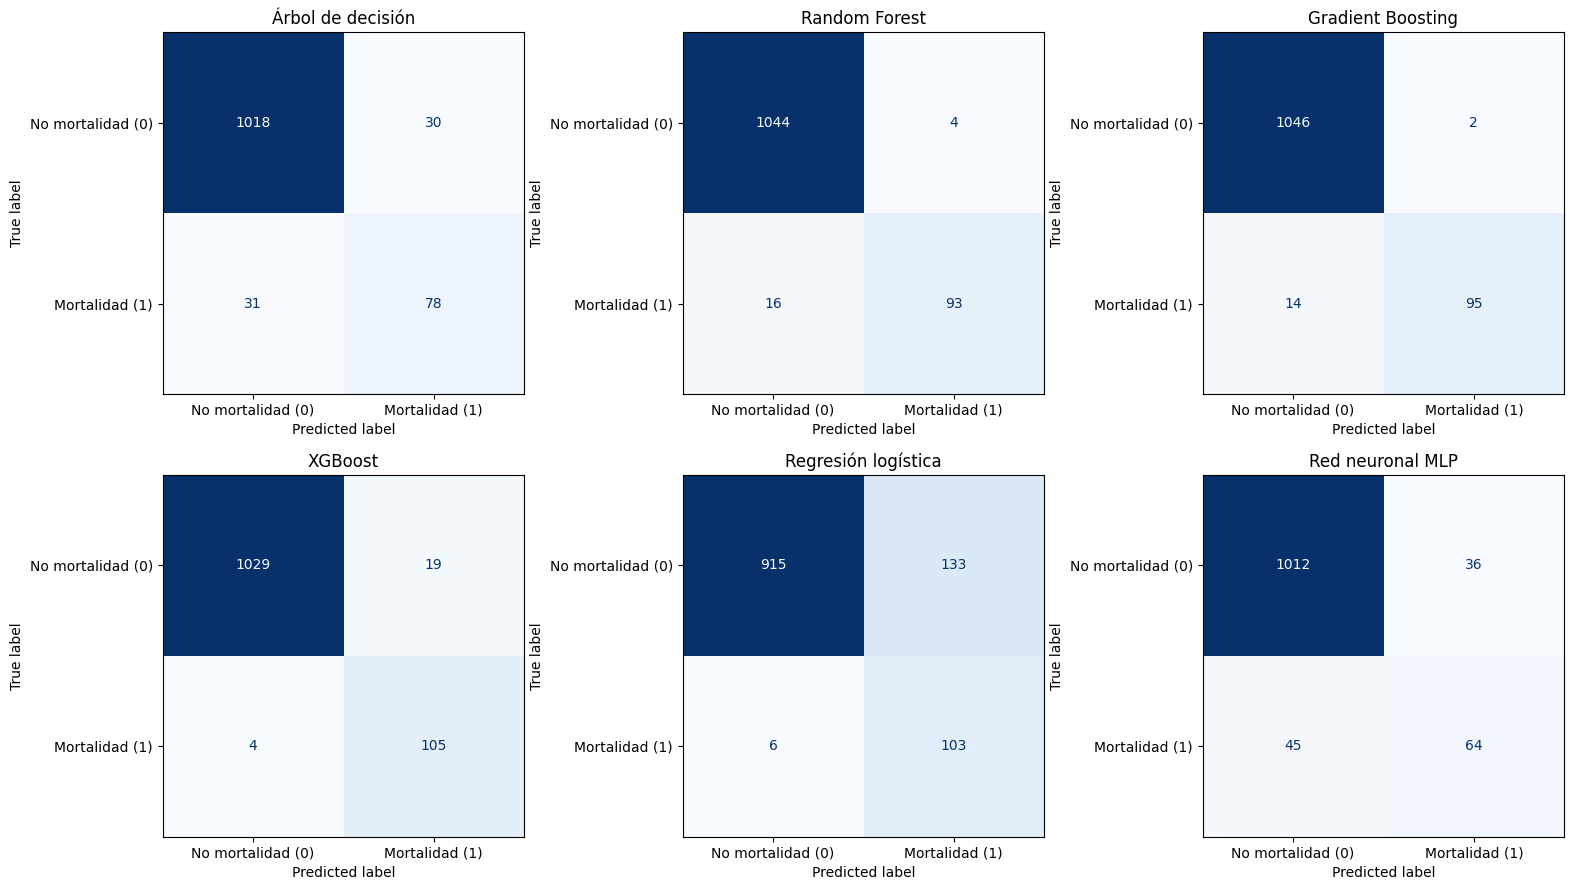


Árbol de decisión


,Pred_0,Pred_1
Real_0,1018,30
Real_1,31,78



Random Forest


,Pred_0,Pred_1
Real_0,1044,4
Real_1,16,93



Gradient Boosting


...

,Pred_0,Pred_1
Real_0,1029,19
Real_1,4,105



Regresión logística


,Pred_0,Pred_1
Real_0,915,133
Real_1,6,103



Red neuronal MLP


,Pred_0,Pred_1
Real_0,1012,36
Real_1,45,64


In [69]:
# ============================================================
# MATRICES DE CONFUSIÓN DE LOS MEJORES MODELOS CARGADOS
# ============================================================
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def to_string_df(X):
    X = pd.DataFrame(X).copy()
    return X.astype(str).fillna("missing").apply(lambda s: s.str.strip())


ARTIFACTOS = {
    "Árbol de decisión": Path("artifacts_modelos/final_model.joblib"),
    "Random Forest": Path("artifacts_modelos/best_rf.joblib"),
    "Gradient Boosting": Path("artifacts_gb/best_gb.joblib"),
    "XGBoost": Path("artifacts_xgb/best_xgb_no_smote.joblib"),
    "Regresión logística": Path("artifacts_modelos/best_logistic_regression.joblib"),
    "Red neuronal MLP": Path("artifacts_modelos/best_mlp.joblib"),
}

archivos_faltantes = [
    str(ruta) for ruta in ARTIFACTOS.values()
    if not ruta.exists()
]

if archivos_faltantes:
    raise FileNotFoundError(
        "No se encontraron estos modelos guardados:\n"
        + "\n".join(archivos_faltantes)
    )

X_test = joblib.load("artifacts_modelos/X_test.joblib")
y_test = joblib.load("artifacts_modelos/y_test.joblib")
modelos_mejores = {
    nombre: joblib.load(ruta)
    for nombre, ruta in ARTIFACTOS.items()
}

matrices_confusion = {}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (nombre, modelo) in zip(axes, modelos_mejores.items()):
    y_pred = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, y_pred, labels=[0, 1])
    matrices_confusion[nombre] = matriz

    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["No mortalidad (0)", "Mortalidad (1)"]
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# Mostrar y guardar cada matriz como tabla.
matrices_confusion_df = {}
for nombre, matriz in matrices_confusion.items():
    nombre_archivo = (
        nombre.lower()
        .replace(" ", "_")
        .replace("ó", "o")
        .replace("í", "i")
    )
    matriz_df = pd.DataFrame(
        matriz,
        index=["Real_0", "Real_1"],
        columns=["Pred_0", "Pred_1"]
    )
    matrices_confusion_df[nombre] = matriz_df
    matriz_df.to_csv(f"matriz_confusion_{nombre_archivo}.csv")
    print(f"\n{nombre}")
    display(matriz_df)


In [70]:
# ============================================================
# TABLA COMPARATIVA DE LOS MEJORES MODELOS
# ============================================================
from pathlib import Path

modelos_comparacion = {
    "Árbol de decisión": Path("artifacts_modelos/final_model.joblib"),
    "Random Forest": Path("artifacts_modelos/best_rf.joblib"),
    "Gradient Boosting": Path("artifacts_gb/best_gb.joblib"),
    "XGBoost": Path("artifacts_xgb/best_xgb_no_smote.joblib"),
    "Regresión logística": Path("artifacts_modelos/best_logistic_regression.joblib"),
    "Red neuronal MLP": Path("artifacts_modelos/best_mlp.joblib"),
}

archivos_faltantes = [
    str(ruta) for ruta in modelos_comparacion.values()
    if not ruta.exists()
]

if archivos_faltantes:
    raise FileNotFoundError(
        "No se encontraron estos modelos guardados:\n"
        + "\n".join(archivos_faltantes)
    )

X_test_comparacion = joblib.load("artifacts_modelos/X_test.joblib")
y_test_comparacion = joblib.load("artifacts_modelos/y_test.joblib")

resultados_comparacion = []

for nombre, ruta in modelos_comparacion.items():
    modelo = joblib.load(ruta)
    y_pred_modelo = modelo.predict(X_test_comparacion)
    matriz = confusion_matrix(
        y_test_comparacion,
        y_pred_modelo,
        labels=[0, 1]
    )
    tn, fp, fn, tp = matriz.ravel()

    especificidad = tn / (tn + fp) if (tn + fp) else 0.0
    sensibilidad = tp / (tp + fn) if (tp + fn) else 0.0

    if hasattr(modelo, "predict_proba"):
        y_proba_modelo = modelo.predict_proba(X_test_comparacion)[:, 1]
        roc_auc = roc_auc_score(y_test_comparacion, y_proba_modelo)
    else:
        roc_auc = np.nan

    resultados_comparacion.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test_comparacion, y_pred_modelo),
        "balanced_accuracy": balanced_accuracy_score(y_test_comparacion, y_pred_modelo),
        "precision": precision_score(y_test_comparacion, y_pred_modelo, zero_division=0),
        "recall": sensibilidad,
        "specificity": especificidad,
        "f1": f1_score(y_test_comparacion, y_pred_modelo, zero_division=0),
        "roc_auc": roc_auc,
        "youden": sensibilidad + especificidad - 1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

comparacion_modelos_df = (
    pd.DataFrame(resultados_comparacion)
    .sort_values(
        by=["youden", "recall", "balanced_accuracy", "f1", "roc_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("TABLA COMPARATIVA DE LOS MEJORES MODELOS")
display(comparacion_modelos_df.round(4))

comparacion_modelos_df.to_csv(
    "comparacion_modelos_test.csv",
    index=False
)
print("Tabla guardada en: comparacion_modelos_test.csv")


TABLA COMPARATIVA DE LOS MEJORES MODELOS


,modelo,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,XGBoost,0.9801,0.9726,0.8468,0.9633,0.9819,0.9013,0.9963,0.9452,1029,19,4,105
1,Gradient Boosting,0.9862,0.9348,0.9794,0.8716,0.9981,0.9223,0.9979,0.8697,1046,2,14,95
2,Random Forest,0.9827,0.9247,0.9588,0.8532,0.9962,0.9029,0.9963,0.8494,1044,4,16,93
3,Regresión logística,0.8799,0.9090,0.4364,0.9450,0.8731,0.5971,0.9595,0.8180,915,133,6,103
4,Árbol de decisión,0.9473,0.8435,0.7222,0.7156,0.9714,0.7189,0.8474,0.6870,1018,30,31,78
5,Red neuronal MLP,0.9300,0.7764,0.6400,0.5872,0.9656,0.6124,0.9519,0.5528,1012,36,45,64


Tabla guardada en: comparacion_modelos_test.csv


In [71]:
# ============================================================
# VARIABLES MÁS IMPORTANTES DEL MEJOR MODELO
# ============================================================
from pathlib import Path

# La tabla ya está ordenada por Youden; la primera fila identifica
# el modelo ganador evaluado sobre el conjunto de prueba.
comparacion_modelos_df = pd.read_csv("comparacion_modelos_test.csv")
nombre_mejor_modelo = comparacion_modelos_df.iloc[0]["modelo"]

rutas_modelos = {
    "Árbol de decisión": Path("artifacts_modelos/final_model.joblib"),
    "Random Forest": Path("artifacts_modelos/best_rf.joblib"),
    "Gradient Boosting": Path("artifacts_gb/best_gb.joblib"),
    "XGBoost": Path("artifacts_xgb/best_xgb_no_smote.joblib"),
    "Regresión logística": Path("artifacts_modelos/best_logistic_regression.joblib"),
    "Red neuronal MLP": Path("artifacts_modelos/best_mlp.joblib"),
}

if nombre_mejor_modelo not in rutas_modelos:
    raise KeyError(
        f"No existe una ruta registrada para el modelo ganador: {nombre_mejor_modelo}"
    )

ruta_mejor_modelo = rutas_modelos[nombre_mejor_modelo]
if not ruta_mejor_modelo.exists():
    raise FileNotFoundError(f"No se encontró el modelo ganador: {ruta_mejor_modelo}")

modelo_ganador = joblib.load(ruta_mejor_modelo)

# Los modelos guardados son pipelines: separamos el preprocesamiento
# del estimador para recuperar los nombres de las variables transformadas.
preprocessor_ganador = modelo_ganador.named_steps["prep"]
estimador_ganador = modelo_ganador.named_steps["model"]
variables_transformadas = preprocessor_ganador.get_feature_names_out()

if hasattr(estimador_ganador, "feature_importances_"):
    importancias_ganador = estimador_ganador.feature_importances_
    tipo_importancia = "feature_importances_"
elif hasattr(estimador_ganador, "coef_"):
    importancias_ganador = np.abs(estimador_ganador.coef_).ravel()
    tipo_importancia = "valor absoluto de coeficientes"
else:
    raise AttributeError(
        f"El modelo {nombre_mejor_modelo} no expone importancias ni coeficientes."
    )

if len(variables_transformadas) != len(importancias_ganador):
    raise ValueError(
        "El número de variables transformadas no coincide con el número de importancias: "
        f"{len(variables_transformadas)} frente a {len(importancias_ganador)}."
    )

variables_importantes_df = (
    pd.DataFrame({
        "modelo": nombre_mejor_modelo,
        "variable": variables_transformadas,
        "importancia": importancias_ganador,
    })
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

print(f"Mejor modelo: {nombre_mejor_modelo}")
print(f"Importancias calculadas mediante: {tipo_importancia}")
print("TOP 20 VARIABLES MÁS IMPORTANTES")
display(variables_importantes_df.head(20))

variables_importantes_df.to_csv(
    "variables_importantes_mejor_modelo.csv",
    index=False
)
print("Ranking guardado en: variables_importantes_mejor_modelo.csv")


Mejor modelo: XGBoost
Importancias calculadas mediante: feature_importances_
TOP 20 VARIABLES MÁS IMPORTANTES


,modelo,variable,importancia
0,XGBoost,num__1. ¿cuántas actividades realiza sólo?,0.100875
1,XGBoost,num__puntaje cam,0.067783
2,XGBoost,cat__disfagia orofaringea_nan,0.064163
3,XGBoost,cat__barthel basal - alimentación_nan,0.058972
4,XGBoost,num__diagnóstico geriátrico infeccioso (choice...,0.035959
5,XGBoost,num__4. ¿cuántas actividades no realiza?,0.025715
6,XGBoost,cat__frail - fatiga_nan,0.023989
7,XGBoost,num__infección por covid-19 confirmado?,0.023559
8,XGBoost,num__puntaje manual lawton y brody,0.022882
9,XGBoost,cat__otros antecedentes_nan,0.022481


Ranking guardado en: variables_importantes_mejor_modelo.csv


In [22]:
# ============================================================
# REENTRENAMIENTO FINAL CON LOS MEJORES HIPERPARAMETROS
# ============================================================
# Entrena una vez cada técnica usando los mejores resultados guardados.
import ast
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

if not all(name in globals() for name in ["X_train", "X_test", "y_train", "y_test"]):
    raise RuntimeError("Ejecuta primero las celdas de preparación y división train/test.")

ARTIFACTS_REEVAL_DIR = Path("artifacts_modelos")
ARTIFACTS_REEVAL_DIR.mkdir(exist_ok=True)


def _clean_value(value):
    if isinstance(value, str):
        text = value.strip()
        if text.lower() in {"none", "nan", "null"}:
            return None
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return value
    if pd.isna(value):
        return None
    return value


def _best_row(table):
    ranking = [c for c in ["youden", "recall", "balanced_accuracy", "f1", "roc_auc", "mean_test_score"] if c in table.columns]
    if not ranking:
        raise ValueError("No se encontró una métrica para seleccionar el mejor resultado.")
    return table.sort_values(ranking, ascending=False, na_position="last").iloc[0]


def _load_tables(*paths):
    tables = []
    for path in paths:
        path = Path(path)
        if path.exists():
            loaded = pd.read_csv(path) if path.suffix == ".csv" else joblib.load(path)
            tables.append(loaded if isinstance(loaded, pd.DataFrame) else pd.DataFrame(loaded))
    if not tables:
        raise FileNotFoundError(f"No se encontró ningún resultado en: {paths}")
    return pd.concat(tables, ignore_index=True)


def _metric_row(name, model):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities) if probabilities is not None and y_test.nunique() > 1 else np.nan,
        "youden": sensitivity + specificity - 1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def _to_string_frame(values):
    return pd.DataFrame(values).astype(str).fillna("missing").apply(lambda series: series.str.strip())


def _make_preprocessor(X_reference):
    numeric_columns = X_reference.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_columns = [c for c in X_reference.columns if c not in numeric_columns]
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_columns),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("to_str", FunctionTransformer(_to_string_frame, validate=False)),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_columns),
    ])


X_train = X_train.copy()
X_test = X_test.copy()
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)
y_train = y_train.copy()
y_test = y_test.copy()

results_tree = _load_tables("results_no_smote.pkl", "results_smote.pkl")
row_tree = _best_row(results_tree)
tree_params = {
    f"model__{key}": _clean_value(row_tree[key])
    for key in ["criterion", "max_features", "max_depth", "class_weight"]
    if key in row_tree.index
}
use_smote_tree = bool(_clean_value(row_tree.get("use_smote", False)))

row_rf = _best_row(_load_tables("results_random_forest.csv"))
rf_params = {key: _clean_value(row_rf[key]) for key in row_rf.index if str(key).startswith("model__")}
row_gb = _best_row(_load_tables("results_gradient_boosting.csv"))
gb_params = {key: _clean_value(row_gb[key]) for key in row_gb.index if str(key).startswith("model__")}

xgb_tables = [
    pd.DataFrame(joblib.load(path))
    for path in ["checkpoints_xgb/chkpt_xgb_no_smote.pkl", "checkpoints_xgb/chkpt_xgb_smote.pkl"]
    if Path(path).exists()
]
if not xgb_tables:
    raise FileNotFoundError("No se encontraron checkpoints de XGBoost.")
row_xgb = _best_row(pd.concat(xgb_tables, ignore_index=True))
xgb_keys = ["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "min_child_weight", "gamma", "reg_alpha", "reg_lambda", "scale_pos_weight"]
xgb_params = {key: _clean_value(row_xgb[key]) for key in xgb_keys if key in row_xgb.index}
use_smote_xgb = bool(_clean_value(row_xgb.get("usesmote", False)))

row_lr = _best_row(_load_tables("results_logistic_regression_all.csv"))
lr_params = {key: _clean_value(row_lr[key]) for key in row_lr.index if str(key).startswith("model__")}
use_smote_lr = bool(_clean_value(row_lr.get("usesmote", False)))
row_mlp = _best_row(_load_tables("results_mlp_all.csv"))
mlp_params = {key: _clean_value(row_mlp[key]) for key in row_mlp.index if str(key).startswith("model__")}
use_smote_mlp = bool(_clean_value(row_mlp.get("usesmote", False)))


def _build_pipeline(model, params=None, use_smote=False):
    steps = [("prep", _make_preprocessor(X_train))]
    if use_smote:
        minority_count = int(y_train.value_counts().min())
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=max(1, min(5, minority_count - 1)))))
    steps.append(("model", model))
    pipeline = ImbPipeline(steps) if use_smote else Pipeline(steps)
    if params:
        integer_suffixes = {"n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_iter"}
        normalized_params = {}
        for key, value in params.items():
            normalized_key = key if key.startswith("model__") else f"model__{key}"
            if value is not None and any(normalized_key.endswith(suffix) for suffix in integer_suffixes):
                value = int(float(value))
            normalized_params[normalized_key] = value
        pipeline.set_params(**normalized_params)
    return pipeline


models_to_train = {
    "Decision Tree": _build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), tree_params, use_smote_tree),
    "Random Forest": _build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), rf_params),
    "Gradient Boosting": _build_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_params),
    "XGBoost": _build_pipeline(XGBClassifier(objective="binary:logistic", eval_metric="logloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1), xgb_params, use_smote_xgb),
    "Logistic Regression": _build_pipeline(LogisticRegression(random_state=RANDOM_STATE, n_jobs=1), lr_params, use_smote_lr),
    "MLP": _build_pipeline(MLPClassifier(random_state=RANDOM_STATE, early_stopping=True, n_iter_no_change=10), mlp_params, use_smote_mlp),
}

reevaluation_rows = []
for model_name, model_pipeline in models_to_train.items():
    model_pipeline.fit(X_train, y_train)
    reevaluation_rows.append(_metric_row(model_name, model_pipeline))
    file_name = re.sub(r"[^a-z0-9]+", "_", model_name.lower()).strip("_")
    joblib.dump(model_pipeline, ARTIFACTS_REEVAL_DIR / f"reevaluacion_{file_name}.joblib")

reevaluation_df = (
    pd.DataFrame(reevaluation_rows)
    .sort_values(["youden", "recall", "balanced_accuracy", "f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
reevaluation_df.to_csv("reevaluacion_modelos_datos_actuales.csv", index=False)
display(reevaluation_df.round(4))
print("Modelos entrenados una vez con los mejores hiperparametros guardados.")

  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,modelo,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,youden,tn,fp,fn,tp
0,XGBoost,0.9767,0.9748,0.8154,0.9725,0.9771,0.8870,0.9967,0.9496,1024,24,3,106
1,Gradient Boosting,0.9862,0.9348,0.9794,0.8716,0.9981,0.9223,0.9979,0.8697,1046,2,14,95
2,Random Forest,0.9827,0.9247,0.9588,0.8532,0.9962,0.9029,0.9963,0.8494,1044,4,16,93
3,Decision Tree,0.9525,0.9121,0.7015,0.8624,0.9618,0.7737,0.9205,0.8242,1008,40,15,94
4,MLP,0.8885,0.8439,0.4479,0.7890,0.8989,0.5714,0.9313,0.6878,942,106,23,86
5,Logistic Regression,0.6932,0.6621,0.1780,0.6239,0.7004,0.2770,0.6941,0.3242,734,314,41,68


Modelos entrenados una vez con los mejores hiperparametros guardados.


In [2]:
# ============================================================
# TABLA DE PACIENTES FALLECIDOS CON LAS 17 VARIABLES DEL CONSENSO
# ============================================================
import re
import unicodedata
from pathlib import Path

import pandas as pd

DATA_PATH_CONSENSUS = Path("HMA.csv")
TARGET_COL_CONSENSUS = "mortalidad"

CONSENSUS_FEATURES = [
    "1. ¿cuántas actividades realiza sólo?",
    "4. ¿cuántas actividades no realiza?",
    "disfagia orofaringea",
    "puntaje cam",
    "puntaje manual lawton y brody",
    "barthel basal - alimentación",
    "puntaje frail calculado de manera manual",
    "otros antecedentes",
    "diagnóstico geriátrico infeccioso (choice=neumonía)",
    "infección por covid-19 confirmado?",
    "frail - fatiga",
    "barthel actual calculado manual",
    "(mna) mini nutritional assessment",
    "diagnóstico otra enfermedad urológica o nefrológica",
    "mini-mental state examination (mmse)",
    "preparación de la comida",
    "diagnóstico principal agrupado",
]


def normalize_consensus_name(value):
    value = str(value).strip().lower()
    value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("utf-8")
    return re.sub(r"[^a-z0-9]+", "", value)


def column_candidates(column_name):
    candidates = [column_name]
    try:
        candidates.append(column_name.encode("utf-8").decode("latin1"))
    except UnicodeError:
        pass
    return candidates


def resolve_consensus_column(column_name, available_columns):
    for candidate in column_candidates(column_name):
        if candidate in available_columns:
            return candidate

    normalized_available = {
        normalize_consensus_name(column): column for column in available_columns
    }
    for candidate in column_candidates(column_name):
        normalized_candidate = normalize_consensus_name(candidate)
        if normalized_candidate in normalized_available:
            return normalized_available[normalized_candidate]

    raise KeyError(f"No se encontró la variable en HMA.csv: {column_name}")


# Se usa latin1 como respaldo porque el archivo puede contener encabezados con codificación mixta.
try:
    df_consensus = pd.read_csv(DATA_PATH_CONSENSUS)
except UnicodeDecodeError:
    df_consensus = pd.read_csv(DATA_PATH_CONSENSUS, encoding="latin1")

df_consensus.columns = [str(column).strip().lower() for column in df_consensus.columns]
resolved_features = [
    resolve_consensus_column(feature.lower(), df_consensus.columns)
    for feature in CONSENSUS_FEATURES
]
resolved_target = resolve_consensus_column(TARGET_COL_CONSENSUS, df_consensus.columns)

mortality_values = df_consensus[resolved_target].astype(str).str.strip().str.lower()
deceased_values = {"1", "1.0", "si", "sí", "yes", "true", "fallecido", "fallecida", "muerto", "muerta", "muerte", "dead"}
deceased_mask = mortality_values.isin(deceased_values)

pacientes_fallecidos_17 = df_consensus.loc[deceased_mask, resolved_features].copy()
pacientes_fallecidos_17.columns = CONSENSUS_FEATURES

print(f"Pacientes fallecidos encontrados: {len(pacientes_fallecidos_17)}")
print(f"Variables incluidas: {len(pacientes_fallecidos_17.columns)}")
display(pacientes_fallecidos_17)

OUTPUT_DECEASED_17 = "pacientes_fallecidos_17_variables.csv"
pacientes_fallecidos_17.to_csv(OUTPUT_DECEASED_17, index=False, encoding="utf-8-sig")
print(f"Tabla guardada en: {OUTPUT_DECEASED_17}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", lin

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Pacientes fallecidos encontrados: 547
Variables incluidas: 17


C:\Users\Kaos\AppData\Local\Temp\ipykernel_6824\2977127683.py:67: DtypeWarning: Columns (9,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_consensus = pd.read_csv(DATA_PATH_CONSENSUS)


,1. ¿cuántas actividades realiza sólo?,4. ¿cuántas actividades no realiza?,disfagia orofaringea,puntaje cam,puntaje manual lawton y brody,barthel basal - alimentación,puntaje frail calculado de manera manual,otros antecedentes,diagnóstico geriátrico infeccioso (choice=neumonía),infección por covid-19 confirmado?,frail - fatiga,barthel actual calculado manual,(mna) mini nutritional assessment,diagnóstico otra enfermedad urológica o nefrológica,mini-mental state examination (mmse),preparación de la comida,diagnóstico principal agrupado
155,0.0,14.0,Sí,4.0,0.0,Dependiente = 0,3.0,NaN,Checked,No,NaN,0.0,7.0,NaN,10.0,NaN,respiratorias
156,0.0,14.0,No,3.0,1.0,NaN,3.0,NaN,Unchecked,No,NaN,45.0,9.0,NaN,16.0,NaN,infecciosas
157,3.0,10.0,No,0.0,6.0,Independiente = 10,3.0,NaN,Unchecked,No,NaN,75.0,4.0,NaN,26.0,NaN,cáncer
158,2.0,7.0,No,0.0,2.0,NaN,4.0,NaN,Unchecked,No,NaN,25.0,4.0,LESION RENAL AGUDA,26.0,NaN,cáncer
159,3.0,14.0,No,4.0,3.0,NaN,3.0,NaN,Checked,No,NaN,50.0,6.0,LESION RENAL KDIGO 3,12.0,NaN,infecciosas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6419,1.0,NaN,No,3.0,2.0,NaN,4.0,"sahos, covid,",Checked,No,NaN,80.0,11.0,NaN,NaN,Necesita que le preparen y sirvan las comidas,infecciosas
6420,2.0,NaN,No,3.0,5.0,NaN,3.0,"dislipidemia, desprendimiento de retina , obes...",Unchecked,No,NaN,90.0,10.0,NaN,25.0,NaN,infecciosas
6421,4.0,NaN,No,3.0,2.0,NaN,4.0,NaN,Unchecked,No,NaN,45.0,7.0,NaN,NaN,NaN,otras
6422,1.0,NaN,No,3.0,0.0,NaN,3.0,"artrosis,",Unchecked,No,NaN,80.0,14.0,"sindrome cardiorrenal,",NaN,Necesita que le preparen y sirvan las comidas,cardiovascular


Tabla guardada en: pacientes_fallecidos_17_variables.csv


In [3]:
# ============================================================
# IMPORTANCIA DE VARIABLES EN LOS TRES MEJORES MODELOS
# ============================================================
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Gradient Boosting fue serializado con esta función auxiliar.
def to_string_df_for_model(data):
    return pd.DataFrame(data).astype(str).fillna("missing").apply(lambda column: column.str.strip())

setattr(sys.modules["__main__"], "to_string_df", to_string_df_for_model)

MODEL_ARTIFACTS = {
    "XGBoost": Path("artifacts_xgb/best_xgb_no_smote.joblib"),
    "Gradient Boosting": Path("artifacts_gb/best_gb.joblib"),
    "Random Forest": Path("artifacts_modelos/best_rf.joblib"),
}

def load_consensus_model(path):
    model = joblib.load(path)
    if not hasattr(model, "named_steps") or "prep" not in model.named_steps:
        raise ValueError(f"El archivo no contiene un pipeline válido: {path}")
    return model

def original_feature_importance(model):
    preprocessor = model.named_steps["prep"]
    importances = np.asarray(model.named_steps["model"].feature_importances_, dtype=float)
    result = {}

    numeric_columns = list(preprocessor.transformers_[0][2])
    numeric_transformer = preprocessor.transformers_[0][1]
    numeric_names = list(numeric_transformer.get_feature_names_out(numeric_columns))
    numeric_slice = preprocessor.output_indices_["num"]
    for offset, feature in enumerate(numeric_names):
        result[feature] = importances[numeric_slice.start + offset]

    categorical_columns = list(preprocessor.transformers_[1][2])
    encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    categorical_slice = preprocessor.output_indices_["cat"]
    importance_index = categorical_slice.start
    for feature, categories in zip(categorical_columns, encoder.categories_):
        category_count = len(categories)
        result[feature] = importances[importance_index:importance_index + category_count].sum()
        importance_index += category_count

    if categorical_slice.stop != len(importances):
        raise ValueError(
            f"No se pudieron mapear todas las importancias: "
            f"{categorical_slice.stop} frente a {len(importances)}."
        )

    result = pd.Series(result, dtype=float)
    return result / result.sum()

models_consensus = {
    name: load_consensus_model(path)
    for name, path in MODEL_ARTIFACTS.items()
}

importance_by_model = pd.concat(
    {name: original_feature_importance(model) for name, model in models_consensus.items()},
    axis=1,
).fillna(0.0)
importance_by_model["Promedio consenso"] = importance_by_model.mean(axis=1)
importance_by_model["Cobertura acumulada"] = (
    importance_by_model["Promedio consenso"].sort_values(ascending=False).cumsum()
    .reindex(importance_by_model.index)
    .fillna(0.0)
 )
importance_by_model = (
    importance_by_model
    .sort_values("Promedio consenso", ascending=False)
    .reset_index()
    .rename(columns={"index": "Variable"})
 )
importance_by_model.insert(0, "Rango", np.arange(1, len(importance_by_model) + 1))

print("IMPORTANCIA AGRUPADA POR VARIABLE ORIGINAL")
display(importance_by_model.head(30).style.format(
    {column: "{:.4%}" for column in importance_by_model.columns if column not in ["Rango", "Variable"]}
))

print("POSICIÓN DE MMSE EN CADA MODELO")
mmse_table = importance_by_model[
    importance_by_model["Variable"].str.contains("mini-mental state examination", case=False, na=False)
].copy()
display(mmse_table)

importance_by_model.to_csv("importancia_consenso_por_variable.csv", index=False, encoding="utf-8-sig")
print("Tabla guardada en: importancia_consenso_por_variable.csv")

IMPORTANCIA AGRUPADA POR VARIABLE ORIGINAL


,Rango,Variable,XGBoost,Gradient Boosting,Random Forest,Promedio consenso,Cobertura acumulada
0,1,1. ¿cuántas actividades realiza sólo?,10.0875%,40.1419%,41.2948%,30.5081%,30.5081%
1,2,4. ¿cuántas actividades no realiza?,2.5715%,23.1300%,7.1889%,10.9635%,41.4716%
2,3,disfagia orofaringea,7.3070%,6.7818%,13.6616%,9.2502%,50.7217%
3,4,puntaje cam,6.7783%,1.6921%,3.2464%,3.9056%,54.6273%
4,5,puntaje manual lawton y brody,2.2882%,2.8078%,2.7299%,2.6086%,57.2360%
5,6,barthel basal - alimentación,6.4273%,0.0653%,0.0700%,2.1876%,59.4235%
6,7,puntaje frail calculado de manera manual,1.8346%,1.8167%,2.6653%,2.1055%,61.5291%
7,8,otros antecedentes,2.8203%,2.2216%,1.2063%,2.0827%,63.6118%
8,9,diagnóstico geriátrico infeccioso (choice=neumonía),3.5959%,0.6629%,1.6215%,1.9601%,65.5719%
9,10,infección por covid-19 confirmado?,2.3559%,2.7743%,0.2508%,1.7937%,67.3656%


POSICIÓN DE MMSE EN CADA MODELO


,Rango,Variable,XGBoost,Gradient Boosting,Random Forest,Promedio consenso,Cobertura acumulada
14,15,mini-mental state examination (mmse),0.006226,0.009968,0.016212,0.010802,0.737089


Tabla guardada en: importancia_consenso_por_variable.csv


In [4]:
# ============================================================
# SENSIBILIDAD DE LA PREDICCIÓN AL VALOR DE MMSE
# ============================================================
# Mantiene fijo un paciente fallecido y cambia únicamente MMSE.
import numpy as np
import pandas as pd

if "models_consensus" not in globals():
    raise RuntimeError("Ejecuta primero la celda de importancias de los tres modelos.")
if "pacientes_fallecidos_17" not in globals():
    raise RuntimeError("Ejecuta primero la celda de pacientes fallecidos.")

patient_row = pacientes_fallecidos_17.iloc[0].to_dict()
mmse_values = [np.nan, 0.0, 10.0, 20.0, 30.0]
binary_columns = {
    "diagnóstico geriátrico infeccioso (choice=neumonía)",
    "infección por covid-19 confirmado?",
}

def dashboard_value(feature, value):
    if pd.isna(value):
        return np.nan
    if feature in binary_columns:
        return 1 if str(value).strip().lower() in {"si", "sí", "checked", "1", "1.0", "yes"} else 0
    if feature == "disfagia orofaringea":
        normalized = str(value).strip().lower()
        return {"sí": "si", "si": "si", "no": "0", "no sabe": "no sabe"}.get(normalized, value)
    return value

def make_model_input(model, values):
    expected_features = list(model.named_steps["prep"].feature_names_in_)
    row = {feature: np.nan for feature in expected_features}
    for feature, value in values.items():
        if feature in row:
            row[feature] = dashboard_value(feature, value)
    return pd.DataFrame([row])

sensitivity_rows = []
for mmse in mmse_values:
    values = dict(patient_row)
    values["mini-mental state examination (mmse)"] = mmse
    row = {"MMSE usado": "No informado" if pd.isna(mmse) else mmse}
    for model_name, model in models_consensus.items():
        row[model_name] = float(model.predict_proba(make_model_input(model, values))[0, 1])
    sensitivity_rows.append(row)

mmse_sensitivity_df = pd.DataFrame(sensitivity_rows)
display(mmse_sensitivity_df.style.format({
    model_name: "{:.2%}" for model_name in models_consensus
}))
mmse_sensitivity_df.to_csv("sensibilidad_prediccion_mmse.csv", index=False, encoding="utf-8-sig")
print("Tabla guardada en: sensibilidad_prediccion_mmse.csv")

c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without

,MMSE usado,XGBoost,Gradient Boosting,Random Forest
0,No informado,86.08%,73.07%,59.50%
1,0.000000,89.45%,8.26%,76.50%
2,10.000000,89.45%,96.98%,77.50%
3,20.000000,88.39%,95.40%,71.50%
4,30.000000,84.76%,70.29%,60.50%


Tabla guardada en: sensibilidad_prediccion_mmse.csv


In [5]:
# ============================================================
# CALIBRACIÓN PLATT DEL CONSENSO DE MODELOS
# ============================================================
# Separa el train en ajuste y calibración para evitar calibrar sobre
# los mismos datos usados para entrenar cada modelo base.
import sys
from pathlib import Path

import joblib
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

def to_string_df_for_calibration(data):
    return pd.DataFrame(data).astype(str).fillna("missing").apply(lambda column: column.str.strip())

setattr(sys.modules["__main__"], "to_string_df", to_string_df_for_calibration)

CALIBRATION_ARTIFACT_DIR = Path("artifacts_calibrados")
CALIBRATION_ARTIFACT_DIR.mkdir(exist_ok=True)

X_train_calibration = joblib.load("artifacts_modelos/X_train.joblib")
y_train_calibration = joblib.load("artifacts_modelos/y_train.joblib")
X_fit, X_calibration, y_fit, y_calibration = train_test_split(
    X_train_calibration,
    y_train_calibration,
    test_size=0.20,
    stratify=y_train_calibration,
    random_state=42,
 )

calibrated_models = {}
for model_name, model_path in MODEL_ARTIFACTS.items():
    base_model = joblib.load(model_path)
    base_model_for_calibration = clone(base_model)
    base_model_for_calibration.fit(X_fit, y_fit)

    try:
        calibrated_model = CalibratedClassifierCV(
            estimator=base_model_for_calibration,
            method="sigmoid",
            cv="prefit",
        )
    except TypeError:
        calibrated_model = CalibratedClassifierCV(
            base_estimator=base_model_for_calibration,
            method="sigmoid",
            cv="prefit",
        )

    calibrated_model.fit(X_calibration, y_calibration)
    output_path = CALIBRATION_ARTIFACT_DIR / f"{model_name.lower().replace(' ', '_')}_platt.joblib"
    joblib.dump(calibrated_model, output_path)
    calibrated_models[model_name] = calibrated_model
    print(f"{model_name}: calibrador guardado en {output_path}")

print(f"Calibradores generados: {len(calibrated_models)}")
print(f"Filas de ajuste: {len(X_fit)} | Filas de calibración: {len(X_calibration)}")

c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


XGBoost: calibrador guardado en artifacts_calibrados\xgboost_platt.joblib


c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Gradient Boosting: calibrador guardado en artifacts_calibrados\gradient_boosting_platt.joblib
Random Forest: calibrador guardado en artifacts_calibrados\random_forest_platt.joblib
Calibradores generados: 3
Filas de ajuste: 3700 | Filas de calibración: 925


c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - peso hace un año' 'frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


c:\Users\Kaos\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['frail - perdida de peso']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Observaciones en Test: 1157
Variables transformadas: 6006
La escala SHAP corresponde al margen/log-odds del XGBoost base.


C:\Users\Kaos\AppData\Local\Temp\ipykernel_20356\2828468446.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


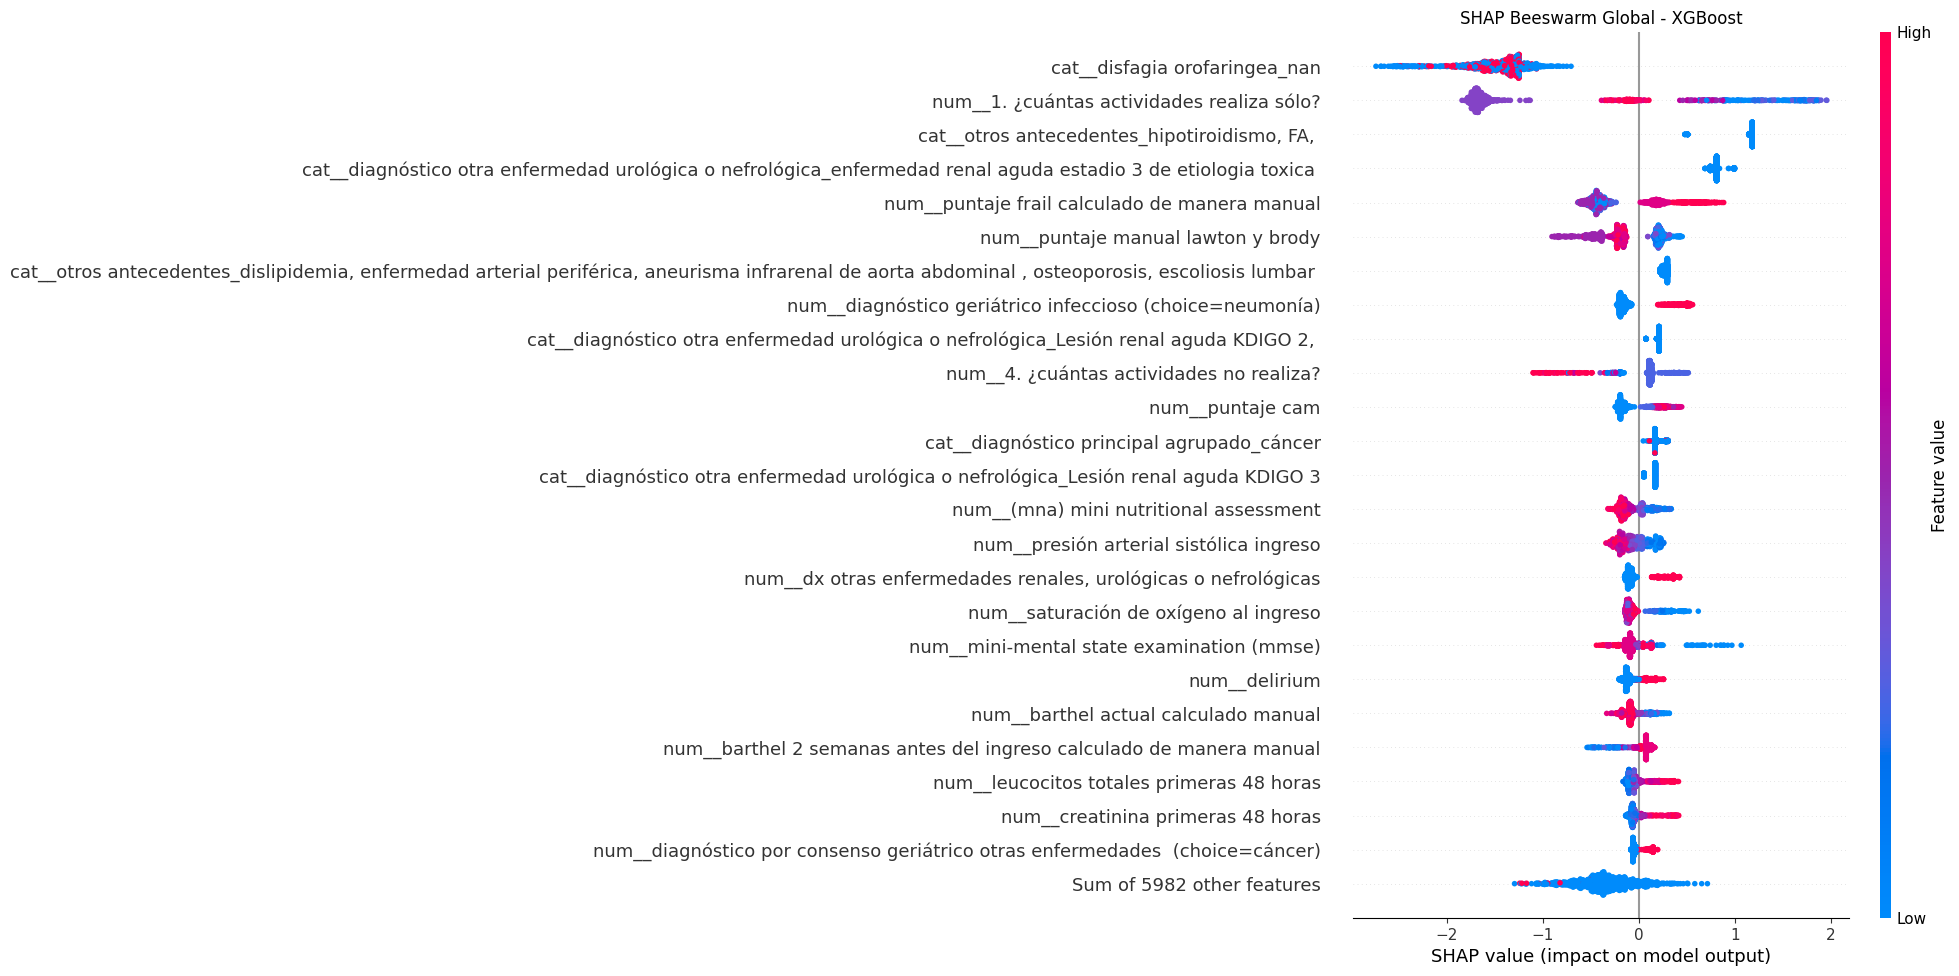

Gráfico guardado en: shap_beeswarm_global_xgboost.png


In [2]:
# ============================================================
# EXPLICABILIDAD GLOBAL SHAP: BEESWARM DE XGBOOST
# ============================================================
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

def to_string_df_for_global_shap(data):
    return pd.DataFrame(data).astype(str).fillna("missing").apply(lambda column: column.str.strip())

setattr(sys.modules["__main__"], "to_string_df", to_string_df_for_global_shap)
setattr(sys.modules["__main__"], "to_string_df_for_global_shap", to_string_df_for_global_shap)

xgb_pipeline = joblib.load(Path("artifacts_xgb/best_xgb_no_smote.joblib"))
X_test_global = joblib.load(Path("artifacts_modelos/X_test.joblib"))
xgb_preprocessor = xgb_pipeline.named_steps["prep"]
xgb_estimator = xgb_pipeline.named_steps["model"]

transformed_test = xgb_preprocessor.transform(X_test_global)
if hasattr(transformed_test, "toarray"):
    X_test_transformed = transformed_test.toarray()
else:
    X_test_transformed = np.asarray(transformed_test)
if X_test_transformed.ndim != 2:
    raise ValueError(f"La matriz transformada debe ser 2-D, no {X_test_transformed.shape}.")

xgb_feature_names = xgb_preprocessor.get_feature_names_out()
xgb_explainer = shap.TreeExplainer(xgb_estimator)
xgb_shap_values = xgb_explainer.shap_values(X_test_transformed)
if isinstance(xgb_shap_values, list):
    xgb_shap_values = xgb_shap_values[-1]

xgb_shap_explanation = shap.Explanation(
    values=np.asarray(xgb_shap_values),
    base_values=xgb_explainer.expected_value,
    data=X_test_transformed,
    feature_names=xgb_feature_names,
 )

print(f"Observaciones en Test: {X_test_transformed.shape[0]}")
print(f"Variables transformadas: {X_test_transformed.shape[1]}")
print("La escala SHAP corresponde al margen/log-odds del XGBoost base.")

plt.figure(figsize=(12, 9))
shap.plots.beeswarm(
    xgb_shap_explanation,
    max_display=25,
    show=False,
 )
plt.title("SHAP Beeswarm Global - XGBoost")
plt.tight_layout()
plt.savefig("shap_beeswarm_global_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado en: shap_beeswarm_global_xgboost.png")